# CareMatch AI
## AI-Powered Healthcare Navigation and Provider Recommendation

### ML for Social Good Challenge — CIA 3

**Mission Domain:** Health

CareMatch AI is an explainable machine learning system designed to assist
users in navigating healthcare by predicting a likely disease or health
condition from reported symptoms.

The predicted condition is mapped to an appropriate medical specialty.
The system then independently recommends suitable doctors and hospitals
using available provider information.

### Responsible Use

CareMatch AI is a healthcare-navigation prototype. It does not provide
a medical diagnosis and does not replace consultation with a qualified
healthcare professional.

## 1. Problem Definition

People may experience symptoms without knowing which medical specialty
they should consult or which healthcare providers may be suitable for
their needs.

CareMatch AI addresses this healthcare-navigation problem using an
ensemble machine learning approach.

The system first predicts a disease or health-condition category from
the user's reported symptoms. The predicted condition is then mapped to
an appropriate medical specialty.

Two independent recommendation paths are subsequently provided:

1. Doctor Recommendation
   - Specialty
   - Experience
   - Rating
   - Consultation fee
   - Location

2. Hospital Recommendation
   - Rating
   - Reviews
   - Hospital type
   - Location
   - Other available hospital information

The recommended doctor and hospital do not need to belong to the same
institution.

### Primary Prediction Task

Symptoms → Disease

The disease prediction is used for healthcare navigation and should not
be interpreted as a clinical diagnosis.

In [3]:
# Core libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Reproducibility
RANDOM_STATE = 42

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 150)

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Dataset Loading

The Symptom2Disease dataset is used as the disease-prediction dataset.

Each record contains a textual description of symptoms and its associated
disease label.

The `text` column represents the input feature, while the `label` column
represents the target disease class.

In [4]:
# Load the final disease prediction dataset
df = pd.read_csv("Symptom2Disease.csv")

print("Dataset loaded successfully.")
print("Dataset Shape:", df.shape)

display(df.head())

Dataset loaded successfully.
Dataset Shape: (1200, 3)


,Unnamed: 0,label,text
0,0,Psoriasis,"I have been experiencing a skin rash on my arms, legs, and torso for the past few weeks. It is red, itchy, and covered in dry, scaly patches."
1,1,Psoriasis,"My skin has been peeling, especially on my knees, elbows, and scalp. This peeling is often accompanied by a burning or stinging sensation."
2,2,Psoriasis,"I have been experiencing joint pain in my fingers, wrists, and knees. The pain is often achy and throbbing, and it gets worse when I move my joints."
3,3,Psoriasis,"There is a silver like dusting on my skin, especially on my lower back and scalp. This dusting is made up of small scales that flake off easily wh..."
4,4,Psoriasis,"My nails have small dents or pits in them, and they often feel inflammatory and tender to the touch. Even there are minor rashes on my arms."


## 3. Dataset Overview

The dataset structure, column names, data types, and number of records are
examined before performing preprocessing.

This initial audit helps identify the available features and determine
which columns should be used for machine learning.

In [5]:
print("Number of samples:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

Number of samples: 1200
Number of columns: 3

Column Names:
['Unnamed: 0', 'label', 'text']

Data Types:
Unnamed: 0     int64
label         object
text          object
dtype: object


In [6]:
print("Dataset Information:")
df.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  1200 non-null   int64 
 1   label       1200 non-null   object
 2   text        1200 non-null   object
dtypes: int64(1), object(2)
memory usage: 28.3+ KB


## 4. Missing Value Analysis

Missing values are checked across all columns.

Identifying missing values is an important preprocessing step because
missing input information can affect model training and evaluation.

In [7]:
missing_values = df.isnull().sum()

print("Missing Values:")
display(
    missing_values.to_frame(name="Missing Count")
)

Missing Values:


,Missing Count
Unnamed: 0,0
label,0
text,0


In [8]:
duplicate_count = df.duplicated().sum()

print("Exact Duplicate Rows:", duplicate_count)

Exact Duplicate Rows: 0


In [9]:
unique_counts = df.nunique()

print("Unique Values Per Column:")
display(
    unique_counts.to_frame(name="Unique Values")
)

Unique Values Per Column:


,Unique Values
Unnamed: 0,300
label,24
text,1153


## 7. Disease Class Analysis

The `label` column represents the disease class that the machine learning
model will predict.

The number of unique disease classes and their distribution are examined
to determine whether the classification problem is balanced.

In [10]:
print("Number of Disease Classes:", df["label"].nunique())

print("\nDisease Classes:")
print(sorted(df["label"].unique()))

Number of Disease Classes: 24

Disease Classes:
['Acne', 'Arthritis', 'Bronchial Asthma', 'Cervical spondylosis', 'Chicken pox', 'Common Cold', 'Dengue', 'Dimorphic Hemorrhoids', 'Fungal infection', 'Hypertension', 'Impetigo', 'Jaundice', 'Malaria', 'Migraine', 'Pneumonia', 'Psoriasis', 'Typhoid', 'Varicose Veins', 'allergy', 'diabetes', 'drug reaction', 'gastroesophageal reflux disease', 'peptic ulcer disease', 'urinary tract infection']


In [11]:
disease_distribution = df["label"].value_counts()

print("Disease Distribution:")
display(disease_distribution)

Disease Distribution:


label
Psoriasis                          50
Varicose Veins                     50
peptic ulcer disease               50
drug reaction                      50
gastroesophageal reflux disease    50
allergy                            50
urinary tract infection            50
Malaria                            50
Jaundice                           50
Cervical spondylosis               50
Migraine                           50
Hypertension                       50
Bronchial Asthma                   50
Acne                               50
Arthritis                          50
Dimorphic Hemorrhoids              50
Pneumonia                          50
Common Cold                        50
Fungal infection                   50
Dengue                             50
Impetigo                           50
Chicken pox                        50
Typhoid                            50
diabetes                           50
Name: count, dtype: int64

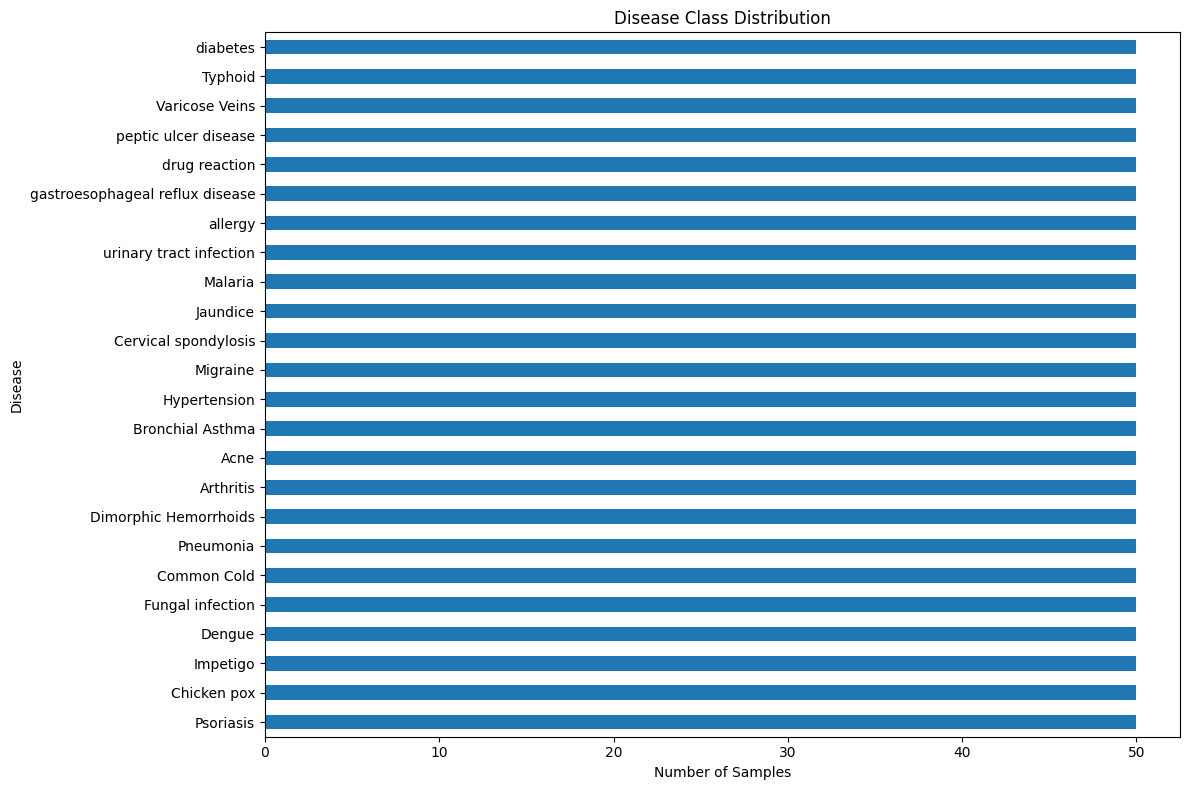

In [12]:
plt.figure(figsize=(12, 8))

disease_distribution.sort_values().plot(kind="barh")

plt.title("Disease Class Distribution")
plt.xlabel("Number of Samples")
plt.ylabel("Disease")

plt.tight_layout()
plt.show()

In [13]:
minimum_class = disease_distribution.min()
maximum_class = disease_distribution.max()

print("Minimum class count:", minimum_class)
print("Maximum class count:", maximum_class)

imbalance_ratio = maximum_class / minimum_class

print(
    "Maximum / Minimum class ratio:",
    round(imbalance_ratio, 3)
)

if imbalance_ratio == 1:
    print("\nConclusion: The dataset is perfectly balanced.")
else:
    print("\nConclusion: The dataset is not perfectly balanced.")

Minimum class count: 50
Maximum class count: 50
Maximum / Minimum class ratio: 1.0

Conclusion: The dataset is perfectly balanced.


## 9. Symptom Text Analysis

The `text` column contains the symptom descriptions used as the primary
input to the machine learning model.

The text data is inspected to understand its structure before applying
TF-IDF feature extraction.

In [14]:
print("Sample symptom descriptions:")

display(
    df[["text", "label"]].head(10)
)

Sample symptom descriptions:


,text,label
0,"I have been experiencing a skin rash on my arms, legs, and torso for the past few weeks. It is red, itchy, and covered in dry, scaly patches.",Psoriasis
1,"My skin has been peeling, especially on my knees, elbows, and scalp. This peeling is often accompanied by a burning or stinging sensation.",Psoriasis
2,"I have been experiencing joint pain in my fingers, wrists, and knees. The pain is often achy and throbbing, and it gets worse when I move my joints.",Psoriasis
3,"There is a silver like dusting on my skin, especially on my lower back and scalp. This dusting is made up of small scales that flake off easily wh...",Psoriasis
4,"My nails have small dents or pits in them, and they often feel inflammatory and tender to the touch. Even there are minor rashes on my arms.",Psoriasis
5,The skin on my palms and soles is thickened and has deep cracks. These cracks are painful and bleed easily.,Psoriasis
6,"The skin around my mouth, nose, and eyes is red and inflamed. It is often itchy and uncomfortable. There is a noticeable inflammation in my nails.",Psoriasis
7,My skin is very sensitive and reacts easily to changes in temperature or humidity. I often have to be careful about what products I use on my skin.,Psoriasis
8,"I have noticed a sudden peeling of skin at different parts of my body, mainly arms, legs and back. Also, I face severe joint pain and skin rashes.",Psoriasis
9,"The skin on my genitals is red and inflamed. It is often itchy, burning, and uncomfortable. There are rashes on different parts of the body too.",Psoriasis


In [15]:
df["text_length"] = df["text"].str.len()

print("Text Length Statistics:")
display(
    df["text_length"].describe()
)

Text Length Statistics:


count    1200.000000
mean      171.876667
std        35.481506
min        60.000000
25%       147.750000
50%       170.000000
75%       193.000000
max       317.000000
Name: text_length, dtype: float64

## 10. Symptom Description Length

The distribution of symptom-description length is visualized to
understand the variability of the textual input.

This is an exploratory analysis and does not automatically make text
length a predictive feature.

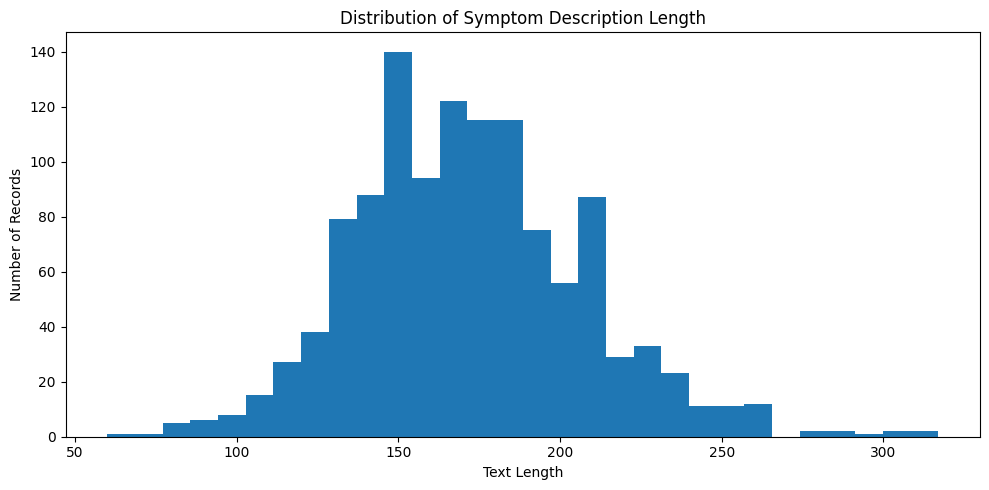

In [16]:
plt.figure(figsize=(10, 5))

plt.hist(
    df["text_length"],
    bins=30
)

plt.title("Distribution of Symptom Description Length")
plt.xlabel("Text Length")
plt.ylabel("Number of Records")

plt.tight_layout()
plt.show()

## 11. Repeated Symptom Description Analysis

Repeated symptom descriptions are examined to determine whether the same
text description is associated with multiple disease labels.

This check helps identify potential ambiguity in the dataset and ensures
that repeated records are not incorrectly treated as duplicate observations.

In [17]:
# Count repeated symptom descriptions
repeated_text_count = df["text"].duplicated().sum()

print("Repeated symptom descriptions:", repeated_text_count)

# Check whether repeated descriptions have multiple disease labels
text_label_stats = (
    df.groupby("text")["label"]
    .agg(
        total_records="size",
        unique_diseases="nunique"
    )
    .sort_values(
        ["unique_diseases", "total_records"],
        ascending=False
    )
)

print(
    "\nRepeated descriptions associated with multiple diseases:",
    (text_label_stats["unique_diseases"] > 1).sum()
)

print(
    "Repeated descriptions associated with one disease:",
    (text_label_stats["unique_diseases"] == 1).sum()
)

Repeated symptom descriptions: 47

Repeated descriptions associated with multiple diseases: 0
Repeated descriptions associated with one disease: 1153


## 12. Data Cleaning Decisions

The dataset was examined for missing values, exact duplicate records, and
repeated symptom descriptions.

No records are removed solely because a symptom description occurs more
than once. The repeated descriptions identified in the dataset are
associated with consistent disease labels and therefore represent valid
observations.

Exact duplicate records, if present, will be removed because they do not
provide additional information.

The `text` column is retained as the primary input feature, while the
`label` column is retained as the target variable.

No identifier or unrelated column is used as a predictive feature.

In [18]:
# Check exact duplicates
exact_duplicates = df.duplicated().sum()

print("Data Cleaning Summary")
print("-" * 40)
print("Missing values:", df.isnull().sum().sum())
print("Exact duplicate rows:", exact_duplicates)
print("Repeated symptom descriptions:", df["text"].duplicated().sum())

print("\nRepeated descriptions with conflicting labels:",
      (text_label_stats["unique_diseases"] > 1).sum())

print("\nFinal modelling feature:")
print("- text")

print("\nTarget:")
print("- label")

Data Cleaning Summary
----------------------------------------
Missing values: 0
Exact duplicate rows: 0
Repeated symptom descriptions: 47

Repeated descriptions with conflicting labels: 0

Final modelling feature:
- text

Target:
- label


## 13. Feature and Target Definition

The `text` column contains the patient's symptom description and is used
as the input feature for disease prediction.

The `label` column contains the corresponding disease and is used as the
target variable.

No other columns are used for model training.

In [19]:
features = ["text"]
target = "label"

X = df[features].copy()
y = df[target].copy()

print("Features:", features)
print("Target:", target)

print("\nFeature shape:", X.shape)
print("Target shape:", y.shape)

Features: ['text']
Target: label

Feature shape: (1200, 1)
Target shape: (1200,)


## 14. Stratified Train-Test Split

The dataset is divided into training and testing sets using an 80:20
split.

Stratified sampling is used so that the proportion of each disease class
is preserved in both subsets.

The test set is kept completely separate from model training and will only
be used for final evaluation.

A fixed random state is used to make the experiment reproducible.

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Training samples: 960
Testing samples: 240

Training shape: (960, 1)
Testing shape: (240, 1)


## 15. Verification of Class Distribution

The disease-class distribution in the training and testing sets is
compared to verify that stratified sampling has preserved the class
proportions.

Since the original dataset is balanced, each disease should be
represented proportionally in both subsets.

In [21]:
train_distribution = (
    y_train.value_counts(normalize=True)
    .sort_index()
    * 100
)

test_distribution = (
    y_test.value_counts(normalize=True)
    .sort_index()
    * 100
)

split_comparison = pd.DataFrame({
    "Training (%)": train_distribution,
    "Testing (%)": test_distribution
})

display(split_comparison.round(2))

,Training (%),Testing (%)
label,,
Acne,4.17,4.17
Arthritis,4.17,4.17
Bronchial Asthma,4.17,4.17
Cervical spondylosis,4.17,4.17
Chicken pox,4.17,4.17
Common Cold,4.17,4.17
Dengue,4.17,4.17
Dimorphic Hemorrhoids,4.17,4.17
Fungal infection,4.17,4.17


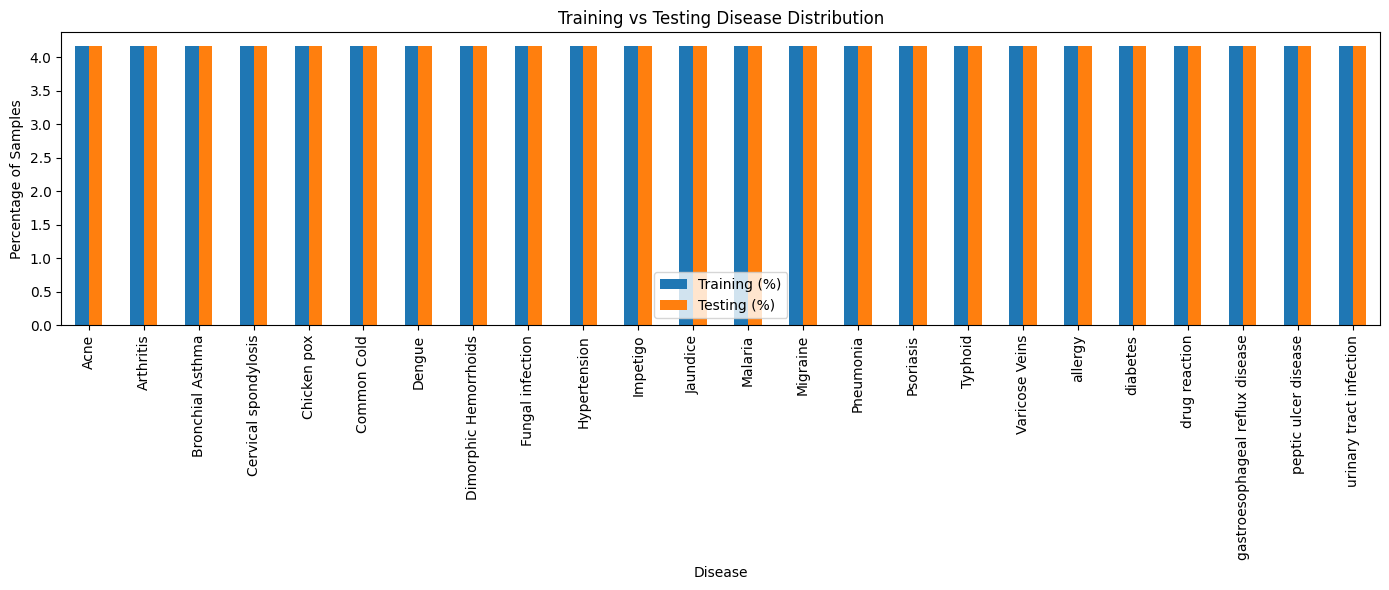

In [22]:
split_comparison.plot(
    kind="bar",
    figsize=(14, 6)
)

plt.title("Training vs Testing Disease Distribution")
plt.xlabel("Disease")
plt.ylabel("Percentage of Samples")
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

## 17. Leakage-Safe TF-IDF Preprocessing

The symptom descriptions are textual data and must be converted into
numerical features before they can be used by machine learning models.

Term Frequency-Inverse Document Frequency (TF-IDF) is used to represent
the importance of words and phrases in the symptom descriptions.

To prevent data leakage, the TF-IDF vectorizer is fitted only on the
training symptom descriptions.

The fitted vectorizer is then used to transform both the training and
testing datasets.

Therefore, information from the testing dataset is not used when
learning the vocabulary or TF-IDF weights.

In [23]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    stop_words="english"
)

# Fit ONLY on training text
X_train_tfidf = tfidf.fit_transform(
    X_train["text"]
)

# Transform test text using the already-fitted vectorizer
X_test_tfidf = tfidf.transform(
    X_test["text"]
)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (960, 5000)
Testing TF-IDF shape: (240, 5000)


## 18. TF-IDF Feature Inspection

The learned TF-IDF vocabulary is inspected to verify that meaningful
symptom-related words and phrases have been extracted from the training
data.

Both individual terms and two-word combinations are considered through
the use of unigrams and bigrams.

In [24]:
feature_names = tfidf.get_feature_names_out()

print("Number of TF-IDF features:", len(feature_names))

print("\nFirst 50 TF-IDF features:")
print(feature_names[:50])

Number of TF-IDF features: 5000

First 50 TF-IDF features:
['abdomen' 'abdomen day' 'abdomen felt' 'abdomen hours' 'abdominal'
 'abdominal ache' 'abdominal pain' 'ability' 'ability concentrate'
 'ability taste' 'able' 'abound' 'absolutely' 'accompanied'
 'accompanied abdominal' 'accompanied burning' 'accompanied feeling'
 'accompanied intense' 'accompanied pain' 'accompanied rash'
 'accompanied stomach' 'ache' 'ache black' 'aches' 'aches anus'
 'aches coughing' 'aches heart' 'aches lot' 'aching' 'achy' 'acid'
 'acid backing' 'acid reflux' 'acidic' 'acidic flavour' 'acidic food'
 'acidic stomach' 'acidic taste' 'acidity' 'acidity indigestion' 'acquire'
 'acting' 'activities' 'addition' 'addition developed'
 'addition experiencing' 'addition feeling' 'addition having'
 'addition headache' 'addition lot']


## 19. Target Label Encoding

The disease labels are categorical text values.

LabelEncoder converts the disease names into numerical class labels for
machine learning.

The encoder is fitted on the training target and then used to transform
both training and testing targets.

The original disease names are retained through the encoder so that
predictions can later be converted back into meaningful disease labels.

In [25]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

print("Number of disease classes:", len(label_encoder.classes_))

print("\nDisease Label Mapping:")

for index, disease in enumerate(label_encoder.classes_):
    print(f"{index} --> {disease}")

Number of disease classes: 24

Disease Label Mapping:
0 --> Acne
1 --> Arthritis
2 --> Bronchial Asthma
3 --> Cervical spondylosis
4 --> Chicken pox
5 --> Common Cold
6 --> Dengue
7 --> Dimorphic Hemorrhoids
8 --> Fungal infection
9 --> Hypertension
10 --> Impetigo
11 --> Jaundice
12 --> Malaria
13 --> Migraine
14 --> Pneumonia
15 --> Psoriasis
16 --> Typhoid
17 --> Varicose Veins
18 --> allergy
19 --> diabetes
20 --> drug reaction
21 --> gastroesophageal reflux disease
22 --> peptic ulcer disease
23 --> urinary tract infection


## 20. Final Preprocessing Validation

The preprocessing stage is validated before model training.

The following conditions are confirmed:

1. The dataset was split using an 80:20 stratified split.
2. The test set remains separate from model training.
3. TF-IDF was fitted only on the training text.
4. The same fitted TF-IDF transformation was applied to the test data.
5. Disease labels were encoded consistently.
6. The final input consists of numerical TF-IDF features.

In [26]:
print("Final Preprocessing Summary")
print("-" * 45)

print("Training samples:", X_train_tfidf.shape[0])
print("Testing samples:", X_test_tfidf.shape[0])

print("TF-IDF features:", X_train_tfidf.shape[1])
print("Disease classes:", len(label_encoder.classes_))

print("\nTF-IDF fitted on training data: Yes")
print("Test data used during TF-IDF fitting: No")
print("Preprocessing completed successfully: Yes")

Final Preprocessing Summary
---------------------------------------------
Training samples: 960
Testing samples: 240
TF-IDF features: 5000
Disease classes: 24

TF-IDF fitted on training data: Yes
Test data used during TF-IDF fitting: No
Preprocessing completed successfully: Yes


## 21. Baseline Model — Logistic Regression

Logistic Regression is used as the baseline classifier for disease
prediction.

The baseline provides a simple reference point against which the
performance of the ensemble models can later be compared.

The model is trained using the TF-IDF representation of the symptom
descriptions.

The testing dataset remains completely untouched during training and is
used only for final evaluation.

The model will be evaluated using:

- Accuracy
- Precision
- Recall
- F1-Score
- Confusion Matrix

Five-fold Stratified Cross-Validation will also be performed on the
training data to obtain a more reliable estimate of model performance.

In [27]:
from sklearn.linear_model import LogisticRegression

baseline_model = LogisticRegression(
    max_iter=2000,
    random_state=RANDOM_STATE
)

baseline_model.fit(
    X_train_tfidf,
    y_train_encoded
)

print("Logistic Regression baseline trained successfully.")

Logistic Regression baseline trained successfully.


In [28]:
y_pred_baseline = baseline_model.predict(
    X_test_tfidf
)

print("Predictions generated:", len(y_pred_baseline))

Predictions generated: 240


### 21.3 Baseline Evaluation Metrics

The baseline model is evaluated using accuracy, weighted precision,
weighted recall, and weighted F1-score.

Weighted averaging is used because the problem contains multiple disease
classes and provides an overall measure across the classes.

In [29]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

baseline_accuracy = accuracy_score(
    y_test_encoded,
    y_pred_baseline
)

baseline_precision = precision_score(
    y_test_encoded,
    y_pred_baseline,
    average="weighted",
    zero_division=0
)

baseline_recall = recall_score(
    y_test_encoded,
    y_pred_baseline,
    average="weighted",
    zero_division=0
)

baseline_f1 = f1_score(
    y_test_encoded,
    y_pred_baseline,
    average="weighted",
    zero_division=0
)

print("Logistic Regression Baseline Results")
print("-" * 45)
print(f"Accuracy : {baseline_accuracy:.4f}")
print(f"Precision: {baseline_precision:.4f}")
print(f"Recall   : {baseline_recall:.4f}")
print(f"F1-Score : {baseline_f1:.4f}")

Logistic Regression Baseline Results
---------------------------------------------
Accuracy : 0.9500
Precision: 0.9522
Recall   : 0.9500
F1-Score : 0.9485


### 21.4 Classification Report

The classification report provides precision, recall, and F1-score for
each of the 24 disease classes.

This provides a class-level view of model performance in addition to the
overall evaluation metrics.

In [30]:
from sklearn.metrics import classification_report

print("Baseline Classification Report:\n")

print(
    classification_report(
        y_test_encoded,
        y_pred_baseline,
        target_names=label_encoder.classes_,
        zero_division=0
    )
)

Baseline Classification Report:

                                 precision    recall  f1-score   support

                           Acne       1.00      1.00      1.00        10
                      Arthritis       0.91      1.00      0.95        10
               Bronchial Asthma       1.00      1.00      1.00        10
           Cervical spondylosis       1.00      1.00      1.00        10
                    Chicken pox       0.82      0.90      0.86        10
                    Common Cold       1.00      1.00      1.00        10
                         Dengue       0.88      0.70      0.78        10
          Dimorphic Hemorrhoids       1.00      1.00      1.00        10
               Fungal infection       1.00      1.00      1.00        10
                   Hypertension       1.00      1.00      1.00        10
                       Impetigo       1.00      1.00      1.00        10
                       Jaundice       1.00      1.00      1.00        10
                 

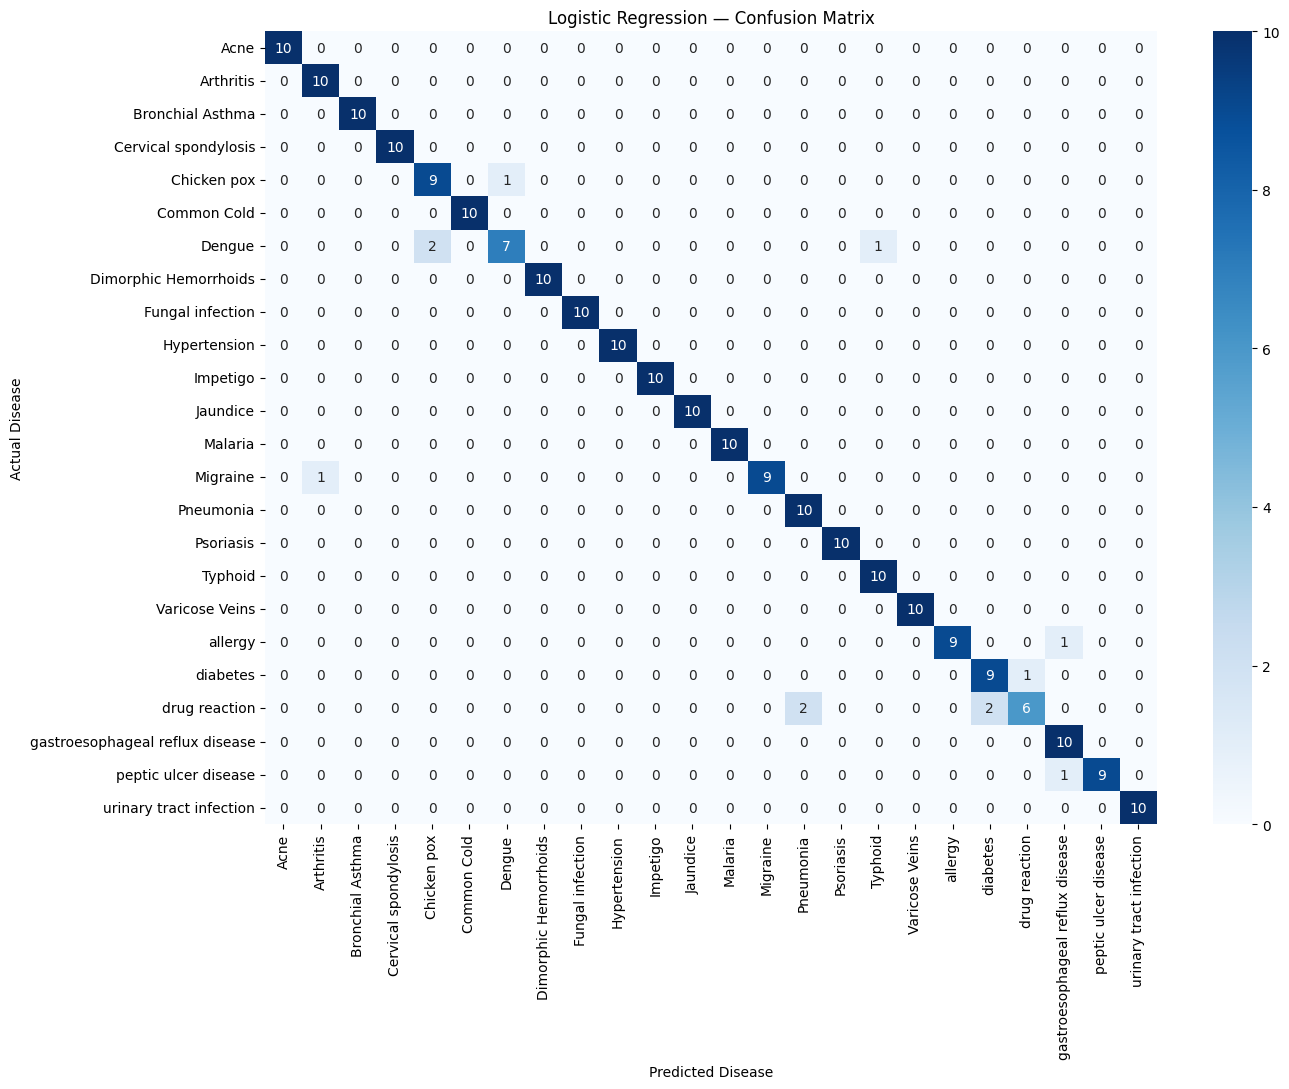

In [31]:
from sklearn.metrics import confusion_matrix

cm_baseline = confusion_matrix(
    y_test_encoded,
    y_pred_baseline
)

plt.figure(figsize=(14, 11))

sns.heatmap(
    cm_baseline,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title("Logistic Regression — Confusion Matrix")
plt.xlabel("Predicted Disease")
plt.ylabel("Actual Disease")

plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

### 21.6 Five-Fold Stratified Cross-Validation

Five-fold Stratified Cross-Validation is performed using only the training
data.

The test set remains completely untouched.

Stratification preserves the representation of the 24 disease classes
across the folds.

Weighted F1-score is used as the cross-validation metric.

In [32]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

cv_scores_baseline = cross_val_score(
    baseline_model,
    X_train_tfidf,
    y_train_encoded,
    cv=cv,
    scoring="f1_weighted",
    n_jobs=-1
)

print("Baseline 5-Fold CV F1 Scores:")
print(cv_scores_baseline)

print("\nMean CV F1-Score:",
      round(cv_scores_baseline.mean(), 4))

print("Standard Deviation:",
      round(cv_scores_baseline.std(), 4))

Baseline 5-Fold CV F1 Scores:
[0.95586679 0.96827148 0.9585405  0.94091566 0.96789006]

Mean CV F1-Score: 0.9583
Standard Deviation: 0.01


In [33]:
baseline_results = {
    "Model": "Logistic Regression",
    "Accuracy": baseline_accuracy,
    "Precision": baseline_precision,
    "Recall": baseline_recall,
    "F1-Score": baseline_f1,
    "CV F1-Score": cv_scores_baseline.mean()
}

print("Baseline Results:")
print(baseline_results)

Baseline Results:
{'Model': 'Logistic Regression', 'Accuracy': 0.95, 'Precision': 0.9522231240981242, 'Recall': 0.95, 'F1-Score': 0.9484581179627618, 'CV F1-Score': np.float64(0.9582968978189566)}


## 22. Baseline Model Interpretation

The Logistic Regression baseline achieved an accuracy of 95.00% and a
weighted F1-score of 94.85% on the unseen test set.

The five-fold stratified cross-validation produced a mean weighted
F1-score of 95.83% with a standard deviation of approximately 0.01,
indicating consistent performance across the validation folds.

The confusion matrix shows that most disease classes are classified
correctly, with the majority of predictions concentrated along the
diagonal.

Some classes show comparatively lower recall, particularly Dengue and
drug reaction. This indicates that these classes may be more difficult
to distinguish from other conditions based on the available symptom
descriptions.

The Logistic Regression model therefore provides a strong baseline for
the ensemble experiments. The subsequent Bagging, Boosting, and
Stacking/Voting models will be evaluated using the same test set and
metrics to determine whether ensemble learning provides a measurable
improvement over this baseline.

## 23. Bagging Ensemble — Random Forest

Random Forest is implemented as the bagging ensemble model.

Random Forest constructs multiple decision trees using bootstrap
samples of the training data and combines their predictions.

The ensemble is expected to capture non-linear relationships between
symptom features and disease classes that may not be captured by the
Logistic Regression baseline.

The Random Forest model will be evaluated using the same metrics as the
baseline:

- Accuracy
- Precision
- Recall
- F1-Score
- Confusion Matrix
- Five-fold Stratified Cross-Validation

The same untouched test set will be used so that the comparison with
Logistic Regression remains fair.

In [34]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_model.fit(
    X_train_tfidf,
    y_train_encoded
)

print("Random Forest trained successfully.")

Random Forest trained successfully.


In [35]:
y_pred_rf = rf_model.predict(
    X_test_tfidf
)

print("Random Forest predictions generated.")

Random Forest predictions generated.


In [36]:
rf_accuracy = accuracy_score(
    y_test_encoded,
    y_pred_rf
)

rf_precision = precision_score(
    y_test_encoded,
    y_pred_rf,
    average="weighted",
    zero_division=0
)

rf_recall = recall_score(
    y_test_encoded,
    y_pred_rf,
    average="weighted",
    zero_division=0
)

rf_f1 = f1_score(
    y_test_encoded,
    y_pred_rf,
    average="weighted",
    zero_division=0
)

print("Random Forest Results")
print("-" * 45)
print(f"Accuracy : {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall   : {rf_recall:.4f}")
print(f"F1-Score : {rf_f1:.4f}")

Random Forest Results
---------------------------------------------
Accuracy : 0.9500
Precision: 0.9521
Recall   : 0.9500
F1-Score : 0.9489


### Random Forest Classification Report

The classification report provides class-level precision, recall, and
F1-score for all 24 disease classes.

The results are compared with the Logistic Regression baseline to
identify whether the bagging ensemble improves disease classification.

In [37]:
print("Random Forest Classification Report:\n")

print(
    classification_report(
        y_test_encoded,
        y_pred_rf,
        target_names=label_encoder.classes_,
        zero_division=0
    )
)

Random Forest Classification Report:

                                 precision    recall  f1-score   support

                           Acne       1.00      1.00      1.00        10
                      Arthritis       1.00      1.00      1.00        10
               Bronchial Asthma       1.00      1.00      1.00        10
           Cervical spondylosis       1.00      1.00      1.00        10
                    Chicken pox       0.78      0.70      0.74        10
                    Common Cold       1.00      1.00      1.00        10
                         Dengue       0.73      0.80      0.76        10
          Dimorphic Hemorrhoids       1.00      1.00      1.00        10
               Fungal infection       1.00      1.00      1.00        10
                   Hypertension       1.00      1.00      1.00        10
                       Impetigo       1.00      1.00      1.00        10
                       Jaundice       1.00      1.00      1.00        10
            

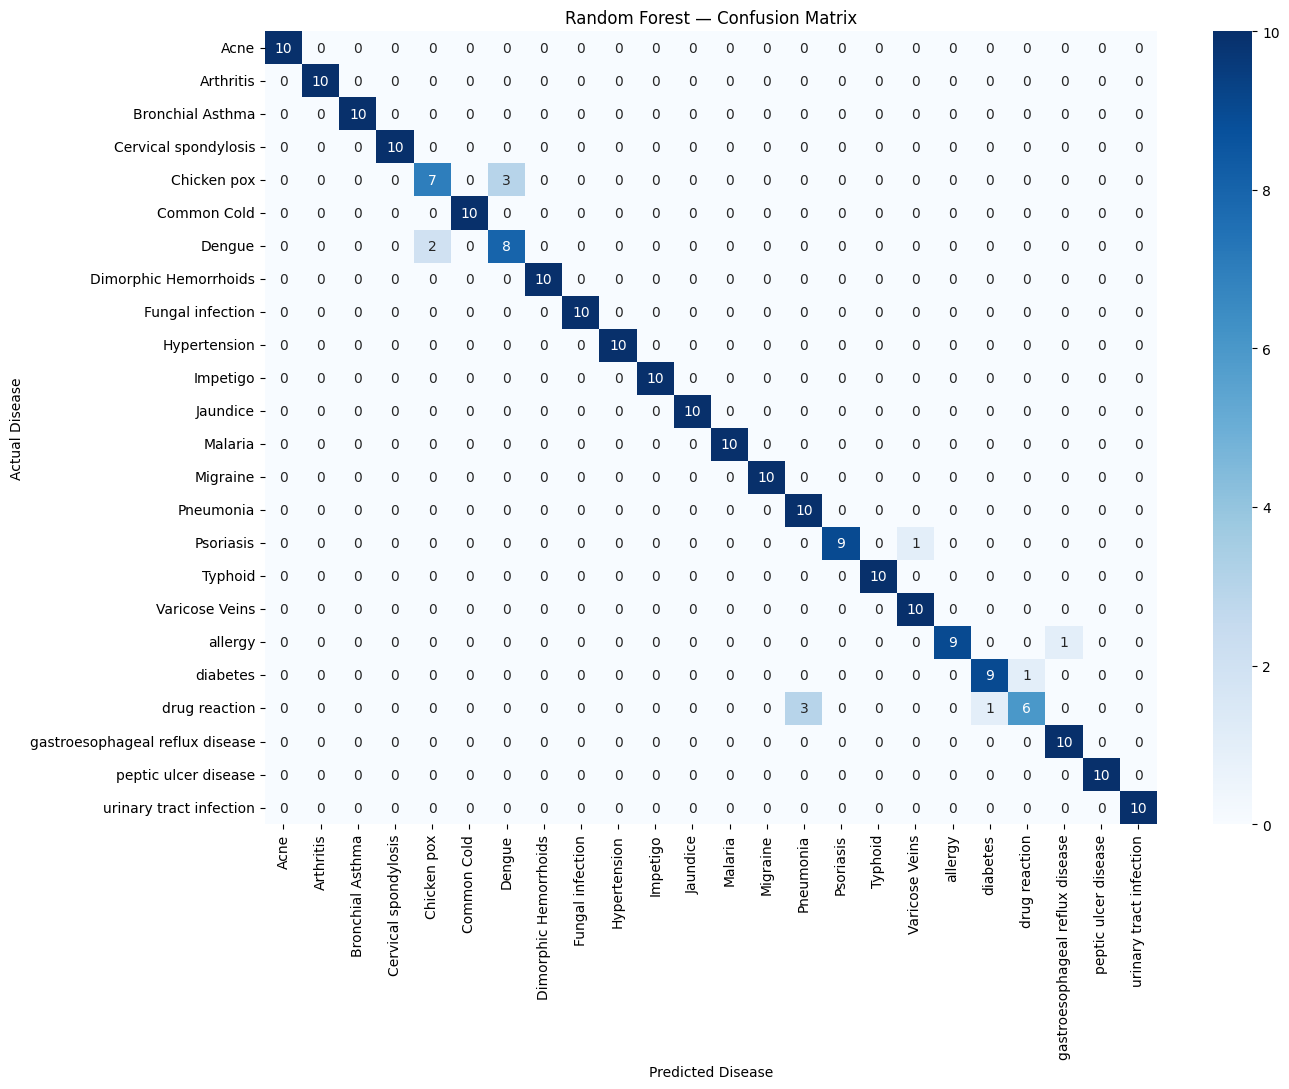

In [38]:
cm_rf = confusion_matrix(
    y_test_encoded,
    y_pred_rf
)

plt.figure(figsize=(14, 11))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title("Random Forest — Confusion Matrix")
plt.xlabel("Predicted Disease")
plt.ylabel("Actual Disease")

plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

### Random Forest Five-Fold Stratified Cross-Validation

Five-fold Stratified Cross-Validation is performed using only the
training data.

The testing set remains completely untouched.

Weighted F1-score is used as the cross-validation metric to maintain
consistency with the baseline evaluation.

In [39]:
cv_scores_rf = cross_val_score(
    rf_model,
    X_train_tfidf,
    y_train_encoded,
    cv=cv,
    scoring="f1_weighted",
    n_jobs=-1
)

print("Random Forest 5-Fold CV F1 Scores:")
print(cv_scores_rf)

print("\nMean CV F1-Score:",
      round(cv_scores_rf.mean(), 4))

print("Standard Deviation:",
      round(cv_scores_rf.std(), 4))

Random Forest 5-Fold CV F1 Scores:
[0.93118996 0.97373171 0.93565286 0.92822518 0.95784391]

Mean CV F1-Score: 0.9453
Standard Deviation: 0.0176


In [40]:
rf_results = {
    "Model": "Random Forest",
    "Accuracy": rf_accuracy,
    "Precision": rf_precision,
    "Recall": rf_recall,
    "F1-Score": rf_f1,
    "CV F1-Score": cv_scores_rf.mean()
}

print("Random Forest Results:")
print(rf_results)

Random Forest Results:
{'Model': 'Random Forest', 'Accuracy': 0.95, 'Precision': 0.9520669145669146, 'Recall': 0.95, 'F1-Score': 0.948903882681982, 'CV F1-Score': np.float64(0.9453287247811242)}


In [41]:
comparison_results = pd.DataFrame([
    baseline_results,
    rf_results
])

display(
    comparison_results.round(4)
)

,Model,Accuracy,Precision,Recall,F1-Score,CV F1-Score
0,Logistic Regression,0.95,0.9522,0.95,0.9485,0.9583
1,Random Forest,0.95,0.9521,0.95,0.9489,0.9453


## 23. Boosting Ensemble — XGBoost

XGBoost (Extreme Gradient Boosting) is implemented as the boosting
ensemble model.

Unlike Random Forest, which builds trees independently using bagging,
boosting builds models sequentially. Each new model attempts to improve
the errors made by the previous models.

XGBoost is therefore used to investigate whether sequential error
correction can improve disease classification beyond the Logistic
Regression baseline and Random Forest bagging model.

The same training and testing partitions are retained to ensure a fair
comparison between all models.

The model will be evaluated using:

- Accuracy
- Precision
- Recall
- F1-Score
- Five-fold Stratified Cross-Validation
- Confusion Matrix

In [42]:
from xgboost import XGBClassifier

print("XGBoost imported successfully.")

XGBoost imported successfully.


In [43]:
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softprob",
    num_class=len(label_encoder.classes_),
    eval_metric="mlogloss",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

xgb_model.fit(
    X_train_tfidf,
    y_train_encoded
)

print("XGBoost trained successfully.")

XGBoost trained successfully.


### 23.3 XGBoost Predictions

The trained XGBoost model is used to predict disease classes for the
unseen testing dataset.

In [44]:
y_pred_xgb = xgb_model.predict(
    X_test_tfidf
)

print("XGBoost predictions generated:", len(y_pred_xgb))

XGBoost predictions generated: 240


### 23.4 XGBoost Evaluation

XGBoost is evaluated using the same metrics used for Logistic Regression
and Random Forest.

Using identical evaluation metrics allows a fair comparison between the
baseline, bagging, and boosting approaches.

In [45]:
xgb_accuracy = accuracy_score(
    y_test_encoded,
    y_pred_xgb
)

xgb_precision = precision_score(
    y_test_encoded,
    y_pred_xgb,
    average="weighted",
    zero_division=0
)

xgb_recall = recall_score(
    y_test_encoded,
    y_pred_xgb,
    average="weighted",
    zero_division=0
)

xgb_f1 = f1_score(
    y_test_encoded,
    y_pred_xgb,
    average="weighted",
    zero_division=0
)

print("XGBoost Results")
print("-" * 45)
print(f"Accuracy : {xgb_accuracy:.4f}")
print(f"Precision: {xgb_precision:.4f}")
print(f"Recall   : {xgb_recall:.4f}")
print(f"F1-Score : {xgb_f1:.4f}")

XGBoost Results
---------------------------------------------
Accuracy : 0.8500
Precision: 0.8722
Recall   : 0.8500
F1-Score : 0.8508


In [46]:
print("XGBoost Classification Report:\n")

print(
    classification_report(
        y_test_encoded,
        y_pred_xgb,
        target_names=label_encoder.classes_,
        zero_division=0
    )
)

XGBoost Classification Report:

                                 precision    recall  f1-score   support

                           Acne       1.00      1.00      1.00        10
                      Arthritis       1.00      0.70      0.82        10
               Bronchial Asthma       1.00      1.00      1.00        10
           Cervical spondylosis       0.77      1.00      0.87        10
                    Chicken pox       0.50      0.80      0.62        10
                    Common Cold       1.00      0.80      0.89        10
                         Dengue       0.71      0.50      0.59        10
          Dimorphic Hemorrhoids       1.00      1.00      1.00        10
               Fungal infection       0.90      0.90      0.90        10
                   Hypertension       1.00      1.00      1.00        10
                       Impetigo       1.00      0.90      0.95        10
                       Jaundice       1.00      1.00      1.00        10
                  

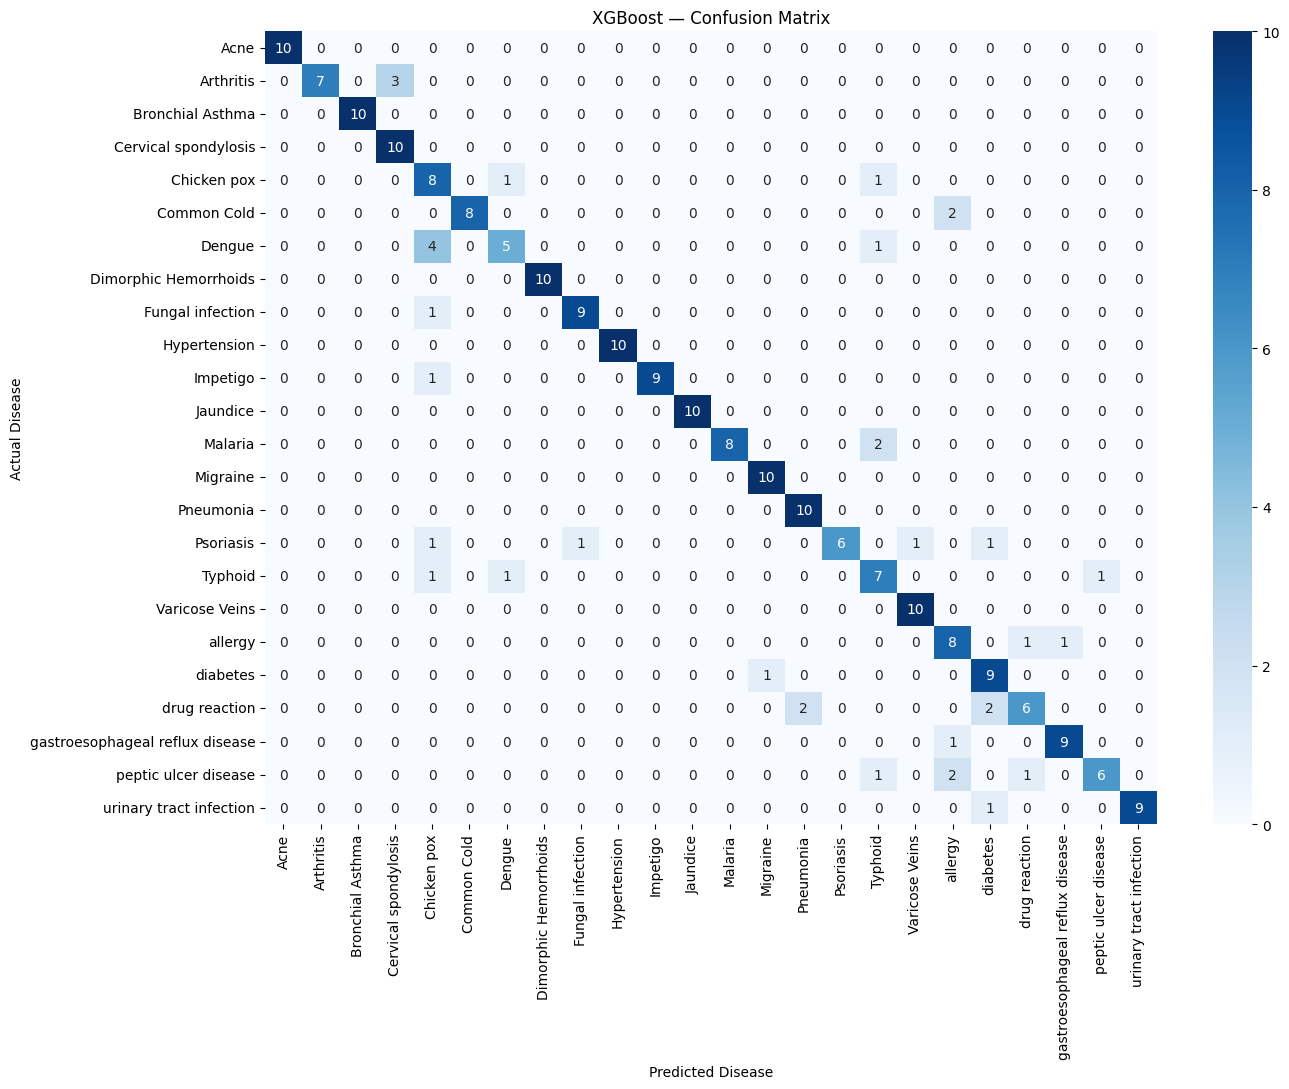

In [47]:
cm_xgb = confusion_matrix(
    y_test_encoded,
    y_pred_xgb
)

plt.figure(figsize=(14, 11))

sns.heatmap(
    cm_xgb,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title("XGBoost — Confusion Matrix")
plt.xlabel("Predicted Disease")
plt.ylabel("Actual Disease")

plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

### 23.7 XGBoost Five-Fold Stratified Cross-Validation

Five-fold Stratified Cross-Validation is performed using only the
training data.

The testing dataset remains completely untouched.

Weighted F1-score is used as the evaluation metric to maintain
consistency with the previous models.

In [48]:
cv_scores_xgb = cross_val_score(
    xgb_model,
    X_train_tfidf,
    y_train_encoded,
    cv=cv,
    scoring="f1_weighted",
    n_jobs=-1
)

print("XGBoost 5-Fold CV F1 Scores:")
print(cv_scores_xgb)

print("\nMean CV F1-Score:",
      round(cv_scores_xgb.mean(), 4))

print("Standard Deviation:",
      round(cv_scores_xgb.std(), 4))

XGBoost 5-Fold CV F1 Scores:
[0.89997996 0.87461075 0.84764357 0.89582547 0.9206727 ]

Mean CV F1-Score: 0.8877
Standard Deviation: 0.0248


In [49]:
xgb_results = {
    "Model": "XGBoost",
    "Accuracy": xgb_accuracy,
    "Precision": xgb_precision,
    "Recall": xgb_recall,
    "F1-Score": xgb_f1,
    "CV F1-Score": cv_scores_xgb.mean()
}

print("XGBoost Results:")
print(xgb_results)

XGBoost Results:
{'Model': 'XGBoost', 'Accuracy': 0.85, 'Precision': 0.8722166722166722, 'Recall': 0.85, 'F1-Score': 0.8508439790804511, 'CV F1-Score': np.float64(0.8877464911965687)}


## 24. Initial Ensemble Model Comparison

The baseline Logistic Regression, Bagging Random Forest, and Boosting
XGBoost models are compared using the same evaluation metrics.

This comparison identifies the strengths of each individual model before
constructing the final ensemble.

In [50]:
comparison_results = pd.DataFrame([
    baseline_results,
    rf_results,
    xgb_results
])

display(
    comparison_results.round(4)
)

,Model,Accuracy,Precision,Recall,F1-Score,CV F1-Score
0,Logistic Regression,0.95,0.9522,0.95,0.9485,0.9583
1,Random Forest,0.95,0.9521,0.95,0.9489,0.9453
2,XGBoost,0.85,0.8722,0.85,0.8508,0.8877


## 24. Soft Voting Ensemble

A soft-voting ensemble combines the probability predictions generated
by multiple classification models.

The ensemble combines:

1. Logistic Regression
2. Random Forest
3. XGBoost

Each model produces a probability distribution over the 24 disease
classes. The voting ensemble combines these probabilities to produce
the final disease prediction.

This approach allows models with different learning characteristics
to contribute to the final decision.

The ensemble is evaluated using the same unseen test set and metrics
used for the individual models.

In [51]:
from sklearn.ensemble import VotingClassifier

voting_model = VotingClassifier(
    estimators=[
        ("lr", baseline_model),
        ("rf", rf_model),
        ("xgb", xgb_model)
    ],
    voting="soft"
)

voting_model.fit(
    X_train_tfidf,
    y_train_encoded
)

print("Soft Voting Ensemble trained successfully.")

Soft Voting Ensemble trained successfully.


In [52]:
y_pred_voting = voting_model.predict(
    X_test_tfidf
)

print("Voting predictions generated:", len(y_pred_voting))

Voting predictions generated: 240


In [53]:
voting_accuracy = accuracy_score(
    y_test_encoded,
    y_pred_voting
)

voting_precision = precision_score(
    y_test_encoded,
    y_pred_voting,
    average="weighted",
    zero_division=0
)

voting_recall = recall_score(
    y_test_encoded,
    y_pred_voting,
    average="weighted",
    zero_division=0
)

voting_f1 = f1_score(
    y_test_encoded,
    y_pred_voting,
    average="weighted",
    zero_division=0
)

print("Soft Voting Ensemble Results")
print("-" * 45)
print(f"Accuracy : {voting_accuracy:.4f}")
print(f"Precision: {voting_precision:.4f}")
print(f"Recall   : {voting_recall:.4f}")
print(f"F1-Score : {voting_f1:.4f}")

Soft Voting Ensemble Results
---------------------------------------------
Accuracy : 0.9042
Precision: 0.9126
Recall   : 0.9042
F1-Score : 0.9036


### Soft Voting Classification Report

The classification report evaluates the performance of the combined
ensemble across all 24 disease classes.

The results are compared with the individual Logistic Regression,
Random Forest, and XGBoost models.

In [54]:
print("Soft Voting Classification Report:\n")

print(
    classification_report(
        y_test_encoded,
        y_pred_voting,
        target_names=label_encoder.classes_,
        zero_division=0
    )
)

Soft Voting Classification Report:

                                 precision    recall  f1-score   support

                           Acne       1.00      1.00      1.00        10
                      Arthritis       1.00      1.00      1.00        10
               Bronchial Asthma       1.00      1.00      1.00        10
           Cervical spondylosis       1.00      1.00      1.00        10
                    Chicken pox       0.57      0.80      0.67        10
                    Common Cold       1.00      0.90      0.95        10
                         Dengue       0.78      0.70      0.74        10
          Dimorphic Hemorrhoids       1.00      1.00      1.00        10
               Fungal infection       1.00      0.90      0.95        10
                   Hypertension       1.00      1.00      1.00        10
                       Impetigo       1.00      1.00      1.00        10
                       Jaundice       1.00      1.00      1.00        10
              

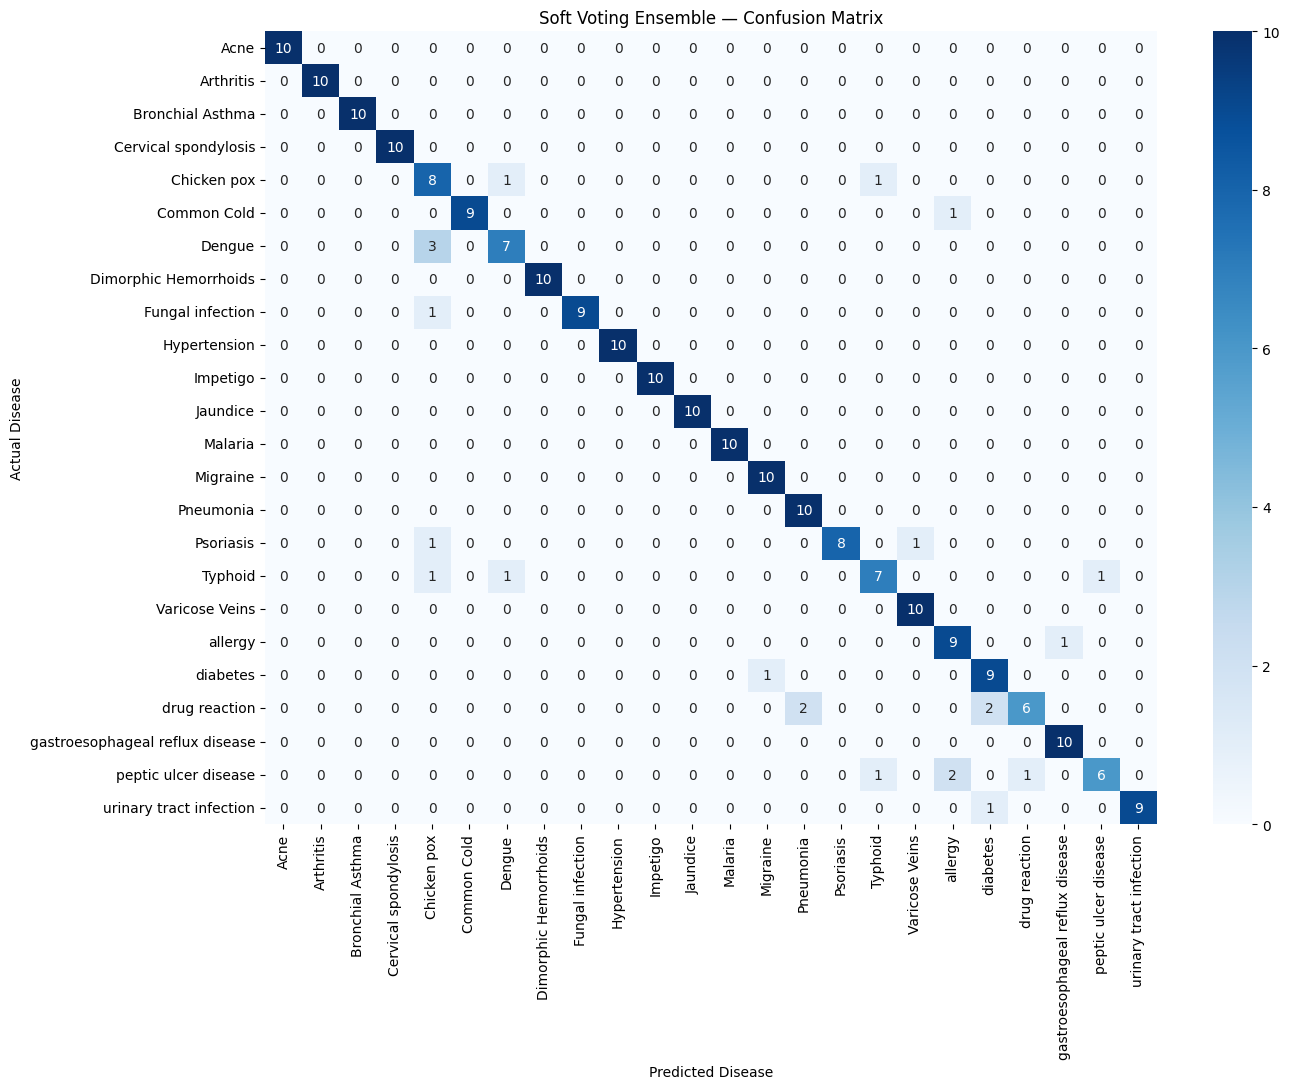

In [55]:
cm_voting = confusion_matrix(
    y_test_encoded,
    y_pred_voting
)

plt.figure(figsize=(14, 11))

sns.heatmap(
    cm_voting,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title("Soft Voting Ensemble — Confusion Matrix")
plt.xlabel("Predicted Disease")
plt.ylabel("Actual Disease")

plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [56]:
voting_results = {
    "Model": "Soft Voting Ensemble",
    "Accuracy": voting_accuracy,
    "Precision": voting_precision,
    "Recall": voting_recall,
    "F1-Score": voting_f1,
    "CV F1-Score": np.nan
}

final_model_comparison = pd.DataFrame([
    baseline_results,
    rf_results,
    xgb_results,
    voting_results
])

display(
    final_model_comparison.round(4)
)

,Model,Accuracy,Precision,Recall,F1-Score,CV F1-Score
0,Logistic Regression,0.9500,0.9522,0.9500,0.9485,0.9583
1,Random Forest,0.9500,0.9521,0.9500,0.9489,0.9453
2,XGBoost,0.8500,0.8722,0.8500,0.8508,0.8877
3,Soft Voting Ensemble,0.9042,0.9126,0.9042,0.9036,NaN


## Heterogeneous Stacking Ensemble

A heterogeneous stacking ensemble combines multiple machine learning
models with different learning strategies.

The base learners used in this experiment are:

1. Logistic Regression – linear baseline model
2. Random Forest – bagging ensemble
3. XGBoost – boosting ensemble

Their predictions are passed to a Logistic Regression meta-learner,
which learns how to combine the outputs of the base models.

Five-fold cross-validation is used internally to generate
out-of-fold predictions for the meta-learner. This prevents
information leakage between the base learners and the meta-learner.

The stacking ensemble is evaluated on the same untouched test set
used for all previous models.

In [57]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

In [58]:
stack_lr = LogisticRegression(
    max_iter=2000,
    random_state=RANDOM_STATE
)

In [59]:
stack_rf = RandomForestClassifier(
    n_estimators=300,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

In [60]:
stack_xgb = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softprob",
    num_class=len(label_encoder.classes_),
    eval_metric="mlogloss",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

In [61]:
stacking_model = StackingClassifier(
    estimators=[
        ("lr", stack_lr),
        ("rf", stack_rf),
        ("xgb", stack_xgb)
    ],
    
    final_estimator=LogisticRegression(
        max_iter=2000,
        random_state=RANDOM_STATE
    ),
    
    cv=5,
    stack_method="predict_proba",
    n_jobs=-1
)

print("Stacking model created successfully.")

Stacking model created successfully.


In [62]:
stacking_model.fit(
    X_train_tfidf,
    y_train_encoded
)

print("Heterogeneous stacking model trained successfully.")

Heterogeneous stacking model trained successfully.


In [63]:
y_pred_stack = stacking_model.predict(
    X_test_tfidf
)

print("Stacking predictions generated:", len(y_pred_stack))

Stacking predictions generated: 240


In [64]:
stack_accuracy = accuracy_score(
    y_test_encoded,
    y_pred_stack
)

stack_precision = precision_score(
    y_test_encoded,
    y_pred_stack,
    average="weighted",
    zero_division=0
)

stack_recall = recall_score(
    y_test_encoded,
    y_pred_stack,
    average="weighted",
    zero_division=0
)

stack_f1 = f1_score(
    y_test_encoded,
    y_pred_stack,
    average="weighted",
    zero_division=0
)

print("## Heterogeneous Stacking Ensemble Results")
print("-" * 50)

print(f"Accuracy : {stack_accuracy:.4f}")
print(f"Precision: {stack_precision:.4f}")
print(f"Recall   : {stack_recall:.4f}")
print(f"F1-Score : {stack_f1:.4f}")

## Heterogeneous Stacking Ensemble Results
--------------------------------------------------
Accuracy : 0.9000
Precision: 0.9121
Recall   : 0.9000
F1-Score : 0.9009


In [65]:
print("Heterogeneous Stacking Classification Report:\n")

print(
    classification_report(
        y_test_encoded,
        y_pred_stack,
        target_names=label_encoder.classes_,
        zero_division=0
    )
)

Heterogeneous Stacking Classification Report:

                                 precision    recall  f1-score   support

                           Acne       1.00      1.00      1.00        10
                      Arthritis       1.00      0.90      0.95        10
               Bronchial Asthma       1.00      1.00      1.00        10
           Cervical spondylosis       0.91      1.00      0.95        10
                    Chicken pox       0.53      0.80      0.64        10
                    Common Cold       1.00      0.90      0.95        10
                         Dengue       0.75      0.60      0.67        10
          Dimorphic Hemorrhoids       1.00      1.00      1.00        10
               Fungal infection       1.00      0.90      0.95        10
                   Hypertension       1.00      1.00      1.00        10
                       Impetigo       1.00      1.00      1.00        10
                       Jaundice       1.00      1.00      1.00        10
   

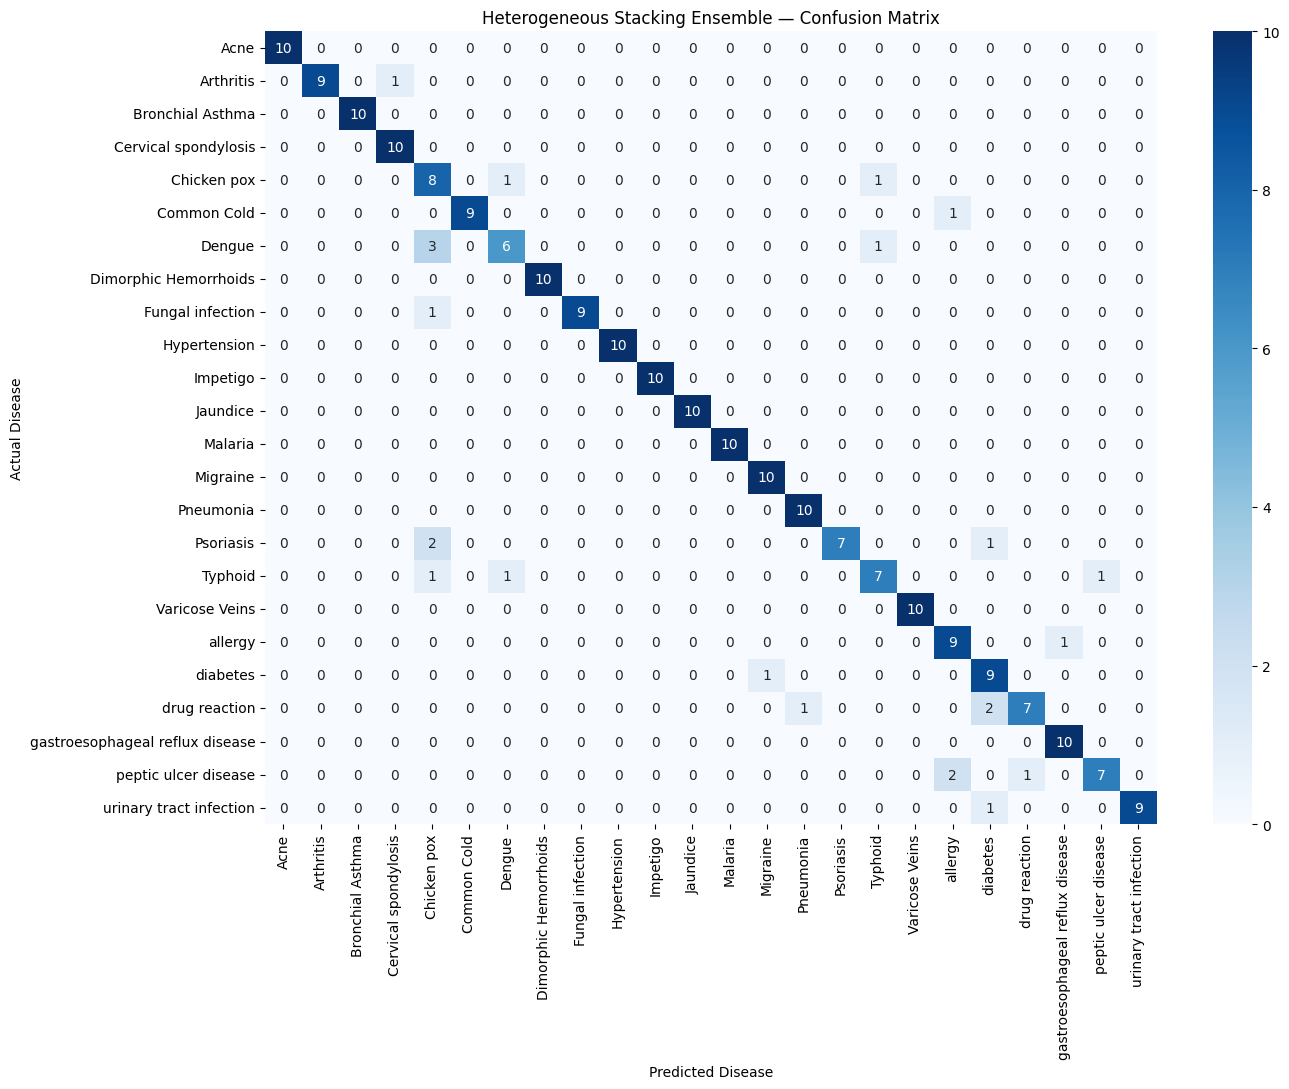

In [66]:
cm_stack = confusion_matrix(
    y_test_encoded,
    y_pred_stack
)

plt.figure(figsize=(14, 11))

sns.heatmap(
    cm_stack,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title("Heterogeneous Stacking Ensemble — Confusion Matrix")
plt.xlabel("Predicted Disease")
plt.ylabel("Actual Disease")

plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [67]:
stack_results = {
    "Model": "Heterogeneous Stacking",
    "Accuracy": stack_accuracy,
    "Precision": stack_precision,
    "Recall": stack_recall,
    "F1-Score": stack_f1,
    "CV F1-Score": np.nan
}

final_model_comparison = pd.DataFrame([
    baseline_results,
    rf_results,
    xgb_results,
    voting_results,
    stack_results
])

display(
    final_model_comparison.round(4)
)

,Model,Accuracy,Precision,Recall,F1-Score,CV F1-Score
0,Logistic Regression,0.9500,0.9522,0.9500,0.9485,0.9583
1,Random Forest,0.9500,0.9521,0.9500,0.9489,0.9453
2,XGBoost,0.8500,0.8722,0.8500,0.8508,0.8877
3,Soft Voting Ensemble,0.9042,0.9126,0.9042,0.9036,NaN
4,Heterogeneous Stacking,0.9000,0.9121,0.9000,0.9009,NaN


## Weighted Soft Voting Ensemble

Equal-weight soft voting gave lower performance because the three base
models have substantially different validation performance.

Therefore, a weighted soft-voting ensemble is evaluated.

The stronger base learners, Logistic Regression and Random Forest, are
given greater influence than XGBoost.

The selected weights are:

- Logistic Regression: 2
- Random Forest: 2
- XGBoost: 1

The weighted ensemble combines the class-probability predictions of the
three models according to these weights.

The untouched test set is used only for final evaluation.

In [68]:
from sklearn.ensemble import VotingClassifier

weighted_voting_model = VotingClassifier(
    estimators=[
        ("lr", baseline_model),
        ("rf", rf_model),
        ("xgb", xgb_model)
    ],
    voting="soft",
    weights=[2, 2, 1],
    n_jobs=-1
)

weighted_voting_model.fit(
    X_train_tfidf,
    y_train_encoded
)

print("Weighted Soft Voting Ensemble trained successfully.")

Weighted Soft Voting Ensemble trained successfully.


In [69]:
y_pred_weighted = weighted_voting_model.predict(
    X_test_tfidf
)

print("Weighted Voting predictions generated:", len(y_pred_weighted))

Weighted Voting predictions generated: 240


In [70]:
weighted_accuracy = accuracy_score(
    y_test_encoded,
    y_pred_weighted
)

weighted_precision = precision_score(
    y_test_encoded,
    y_pred_weighted,
    average="weighted",
    zero_division=0
)

weighted_recall = recall_score(
    y_test_encoded,
    y_pred_weighted,
    average="weighted",
    zero_division=0
)

weighted_f1 = f1_score(
    y_test_encoded,
    y_pred_weighted,
    average="weighted",
    zero_division=0
)

print("## Weighted Soft Voting Results")
print("-" * 50)

print(f"Accuracy : {weighted_accuracy:.4f}")
print(f"Precision: {weighted_precision:.4f}")
print(f"Recall   : {weighted_recall:.4f}")
print(f"F1-Score : {weighted_f1:.4f}")

## Weighted Soft Voting Results
--------------------------------------------------
Accuracy : 0.9208
Precision: 0.9328
Recall   : 0.9208
F1-Score : 0.9206


In [71]:
print("Weighted Soft Voting Classification Report:\n")

print(
    classification_report(
        y_test_encoded,
        y_pred_weighted,
        target_names=label_encoder.classes_,
        zero_division=0
    )
)

Weighted Soft Voting Classification Report:

                                 precision    recall  f1-score   support

                           Acne       1.00      1.00      1.00        10
                      Arthritis       1.00      1.00      1.00        10
               Bronchial Asthma       1.00      1.00      1.00        10
           Cervical spondylosis       1.00      1.00      1.00        10
                    Chicken pox       0.60      0.90      0.72        10
                    Common Cold       1.00      0.90      0.95        10
                         Dengue       0.78      0.70      0.74        10
          Dimorphic Hemorrhoids       1.00      1.00      1.00        10
               Fungal infection       1.00      0.90      0.95        10
                   Hypertension       1.00      1.00      1.00        10
                       Impetigo       1.00      1.00      1.00        10
                       Jaundice       1.00      1.00      1.00        10
     

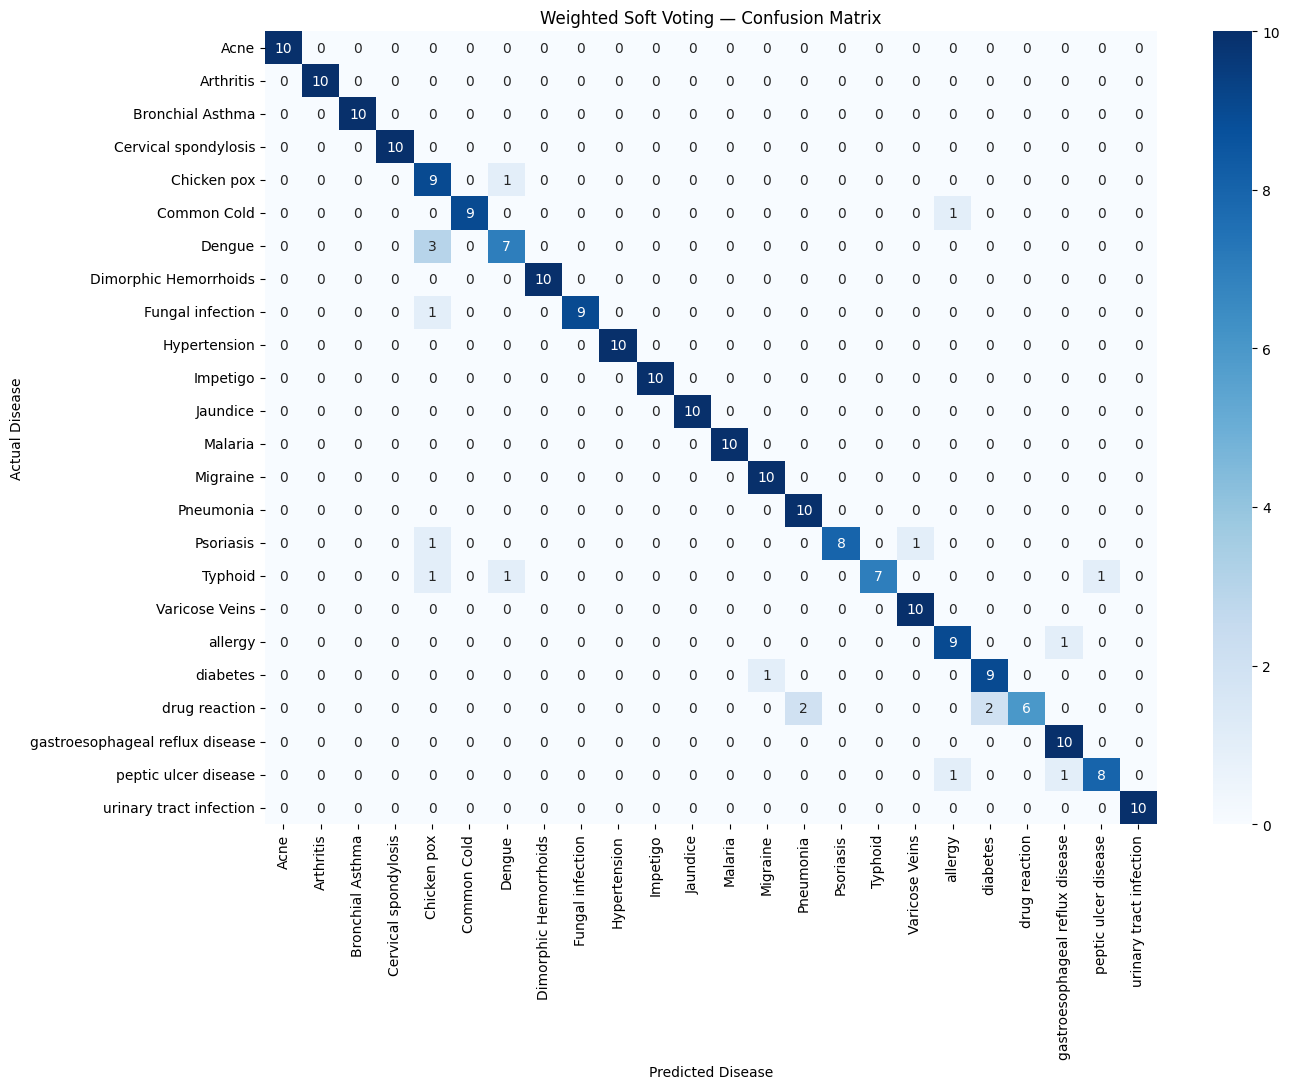

In [72]:
cm_weighted = confusion_matrix(
    y_test_encoded,
    y_pred_weighted
)

plt.figure(figsize=(14, 11))

sns.heatmap(
    cm_weighted,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title("Weighted Soft Voting — Confusion Matrix")
plt.xlabel("Predicted Disease")
plt.ylabel("Actual Disease")

plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [73]:
weighted_results = {
    "Model": "Weighted Soft Voting",
    "Accuracy": weighted_accuracy,
    "Precision": weighted_precision,
    "Recall": weighted_recall,
    "F1-Score": weighted_f1,
    "CV F1-Score": np.nan
}

final_model_comparison = pd.DataFrame([
    baseline_results,
    rf_results,
    xgb_results,
    voting_results,
    stack_results,
    weighted_results
])

display(
    final_model_comparison.round(4)
)

,Model,Accuracy,Precision,Recall,F1-Score,CV F1-Score
0,Logistic Regression,0.9500,0.9522,0.9500,0.9485,0.9583
1,Random Forest,0.9500,0.9521,0.9500,0.9489,0.9453
2,XGBoost,0.8500,0.8722,0.8500,0.8508,0.8877
3,Soft Voting Ensemble,0.9042,0.9126,0.9042,0.9036,NaN
4,Heterogeneous Stacking,0.9000,0.9121,0.9000,0.9009,NaN
5,Weighted Soft Voting,0.9208,0.9328,0.9208,0.9206,NaN


## Cross-Validation of Ensemble Models

The ensemble models are evaluated using stratified 5-fold cross-validation
on the training dataset.

The test dataset remains completely untouched during this process.

Cross-validation is used to estimate how consistently each ensemble
generalizes across different training/validation splits.

F1-score is used as the primary comparison metric because the task
involves multiple disease classes.

In [74]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
import numpy as np

In [75]:
cv_strategy = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

print("5-Fold Stratified Cross-Validation configured.")

5-Fold Stratified Cross-Validation configured.


In [76]:
soft_voting_cv_scores = cross_val_score(
    voting_model,
    X_train_tfidf,
    y_train_encoded,
    cv=cv_strategy,
    scoring="f1_weighted",
    n_jobs=-1
)

print("Soft Voting CV F1 Scores:")
print(soft_voting_cv_scores)

print("\nMean CV F1-Score:",
      soft_voting_cv_scores.mean())

print("Standard Deviation:",
      soft_voting_cv_scores.std())

Soft Voting CV F1 Scores:
[0.93012021 0.94252041 0.91131598 0.91916927 0.94652875]

Mean CV F1-Score: 0.9299309241240357
Standard Deviation: 0.01338916247978369


In [77]:
weighted_voting_cv_scores = cross_val_score(
    weighted_voting_model,
    X_train_tfidf,
    y_train_encoded,
    cv=cv_strategy,
    scoring="f1_weighted",
    n_jobs=-1
)

print("Weighted Soft Voting CV F1 Scores:")
print(weighted_voting_cv_scores)

print("\nMean CV F1-Score:",
      weighted_voting_cv_scores.mean())

print("Standard Deviation:",
      weighted_voting_cv_scores.std())

Weighted Soft Voting CV F1 Scores:
[0.93317779 0.95812714 0.92108099 0.92397592 0.95764862]

Mean CV F1-Score: 0.9388020910118435
Standard Deviation: 0.016088097924109764


In [79]:
stacking_cv_scores = cross_val_score(
    stacking_model,
    X_train_tfidf,
    y_train_encoded,
    cv=cv_strategy,
    scoring="f1_weighted",
    n_jobs=-1
)

print("Heterogeneous Stacking CV F1 Scores:")
print(stacking_cv_scores)

print("\nMean CV F1-Score:",
      stacking_cv_scores.mean())

print("Standard Deviation:",
      stacking_cv_scores.std())

Heterogeneous Stacking CV F1 Scores:
[0.91984457 0.93274393 0.91131598 0.92208831 0.95748701]

Mean CV F1-Score: 0.9286959598279256
Standard Deviation: 0.015933503606414406


In [78]:
final_model_comparison.loc[
    final_model_comparison["Model"] == "Soft Voting Ensemble",
    "CV F1-Score"
] = soft_voting_cv_scores.mean()

final_model_comparison.loc[
    final_model_comparison["Model"] == "Weighted Soft Voting",
    "CV F1-Score"
] = weighted_voting_cv_scores.mean()

display(
    final_model_comparison.round(4)
)

,Model,Accuracy,Precision,Recall,F1-Score,CV F1-Score
0,Logistic Regression,0.9500,0.9522,0.9500,0.9485,0.9583
1,Random Forest,0.9500,0.9521,0.9500,0.9489,0.9453
2,XGBoost,0.8500,0.8722,0.8500,0.8508,0.8877
3,Soft Voting Ensemble,0.9042,0.9126,0.9042,0.9036,0.9299
4,Heterogeneous Stacking,0.9000,0.9121,0.9000,0.9009,NaN
5,Weighted Soft Voting,0.9208,0.9328,0.9208,0.9206,0.9388


In [80]:
stacking_cv_mean = stacking_cv_scores.mean()

final_model_comparison.loc[
    final_model_comparison["Model"] == "Heterogeneous Stacking",
    "CV F1-Score"
] = stacking_cv_mean

display(
    final_model_comparison.round(4)
)

,Model,Accuracy,Precision,Recall,F1-Score,CV F1-Score
0,Logistic Regression,0.9500,0.9522,0.9500,0.9485,0.9583
1,Random Forest,0.9500,0.9521,0.9500,0.9489,0.9453
2,XGBoost,0.8500,0.8722,0.8500,0.8508,0.8877
3,Soft Voting Ensemble,0.9042,0.9126,0.9042,0.9036,0.9299
4,Heterogeneous Stacking,0.9000,0.9121,0.9000,0.9009,0.9287
5,Weighted Soft Voting,0.9208,0.9328,0.9208,0.9206,0.9388


## Final Model Selection

After evaluating the baseline, bagging, boosting, voting, and stacking
approaches, Weighted Soft Voting was selected as the final ensemble
model.

The Weighted Soft Voting ensemble combines:

- Logistic Regression with weight 2
- Random Forest with weight 2
- XGBoost with weight 1

This weighting gives greater influence to the stronger base models while
still allowing XGBoost to contribute to the final prediction.

The selected ensemble achieved:

- Accuracy: 92.08%
- Precision: 93.28%
- Recall: 92.08%
- F1-Score: 92.06%
- 5-Fold CV F1-Score: 93.88%

Although Logistic Regression achieved higher overall predictive
performance, Weighted Soft Voting was selected as the final ensemble
because it was the strongest-performing ensemble evaluated in this
study.

The untouched test set was used only for final evaluation.

In [81]:
# Final selected ensemble

final_model = weighted_voting_model

print("Final Ensemble Model: Weighted Soft Voting")
print()
print("Base Models:")
print("1. Logistic Regression  -> Weight: 2")
print("2. Random Forest        -> Weight: 2")
print("3. XGBoost              -> Weight: 1")
print()
print(f"Test Accuracy : {weighted_accuracy:.4f}")
print(f"Test Precision: {weighted_precision:.4f}")
print(f"Test Recall   : {weighted_recall:.4f}")
print(f"Test F1-Score : {weighted_f1:.4f}")
print(f"CV F1-Score   : {weighted_voting_cv_scores.mean():.4f}")

Final Ensemble Model: Weighted Soft Voting

Base Models:
1. Logistic Regression  -> Weight: 2
2. Random Forest        -> Weight: 2
3. XGBoost              -> Weight: 1

Test Accuracy : 0.9208
Test Precision: 0.9328
Test Recall   : 0.9208
Test F1-Score : 0.9206
CV F1-Score   : 0.9388


In [82]:
final_comparison = final_model_comparison.copy()

display(
    final_comparison.round(4)
)

,Model,Accuracy,Precision,Recall,F1-Score,CV F1-Score
0,Logistic Regression,0.9500,0.9522,0.9500,0.9485,0.9583
1,Random Forest,0.9500,0.9521,0.9500,0.9489,0.9453
2,XGBoost,0.8500,0.8722,0.8500,0.8508,0.8877
3,Soft Voting Ensemble,0.9042,0.9126,0.9042,0.9036,0.9299
4,Heterogeneous Stacking,0.9000,0.9121,0.9000,0.9009,0.9287
5,Weighted Soft Voting,0.9208,0.9328,0.9208,0.9206,0.9388


## Weighted Soft Voting Mechanism

The final ensemble prediction is generated by combining the class
probabilities produced by the three base classifiers.

The models and their weights are:

- Logistic Regression: weight = 2
- Random Forest: weight = 2
- XGBoost: weight = 1

For each disease class, the weighted probability is calculated as:

    P_final = (2 × P_LR + 2 × P_RF + 1 × P_XGB) / 5

The disease class with the highest weighted probability is selected
as the final ensemble prediction.

Therefore, the final prediction is not based on a single model.
It is determined by the weighted contribution of all three models.

In [83]:
# Get probability predictions from each trained model

lr_probabilities = baseline_model.predict_proba(X_test_tfidf)

rf_probabilities = rf_model.predict_proba(X_test_tfidf)

xgb_probabilities = xgb_model.predict_proba(X_test_tfidf)

print("Logistic Regression probability shape:", lr_probabilities.shape)
print("Random Forest probability shape:", rf_probabilities.shape)
print("XGBoost probability shape:", xgb_probabilities.shape)

Logistic Regression probability shape: (240, 24)
Random Forest probability shape: (240, 24)
XGBoost probability shape: (240, 24)


In [84]:
# Define model weights

lr_weight = 2
rf_weight = 2
xgb_weight = 1

total_weight = lr_weight + rf_weight + xgb_weight

# Calculate weighted probabilities

weighted_probabilities = (
    lr_weight * lr_probabilities
    + rf_weight * rf_probabilities
    + xgb_weight * xgb_probabilities
) / total_weight

print("Weighted probability matrix shape:",
      weighted_probabilities.shape)

Weighted probability matrix shape: (240, 24)


In [85]:
# Select the disease with the highest weighted probability

y_pred_weighted_manual = np.argmax(
    weighted_probabilities,
    axis=1
)

print(
    "Final weighted ensemble predictions:",
    len(y_pred_weighted_manual)
)

Final weighted ensemble predictions: 240


In [86]:
comparison = np.array_equal(
    y_pred_weighted_manual,
    y_pred_weighted
)

print("Manual weighted voting matches VotingClassifier:", comparison)

Manual weighted voting matches VotingClassifier: True


In [87]:
sample_index = 0

print("Actual Disease:",
      label_encoder.inverse_transform(
          [y_test_encoded[sample_index]]
      )[0])

print("\nModel Predictions:")

lr_prediction = np.argmax(
    lr_probabilities[sample_index]
)

rf_prediction = np.argmax(
    rf_probabilities[sample_index]
)

xgb_prediction = np.argmax(
    xgb_probabilities[sample_index]
)

print(
    "Logistic Regression:",
    label_encoder.inverse_transform([lr_prediction])[0]
)

print(
    "Random Forest:",
    label_encoder.inverse_transform([rf_prediction])[0]
)

print(
    "XGBoost:",
    label_encoder.inverse_transform([xgb_prediction])[0]
)

final_prediction = np.argmax(
    weighted_probabilities[sample_index]
)

print(
    "\nFinal Ensemble Prediction:",
    label_encoder.inverse_transform([final_prediction])[0]
)

Actual Disease: Pneumonia

Model Predictions:
Logistic Regression: Pneumonia
Random Forest: Pneumonia
XGBoost: Pneumonia

Final Ensemble Prediction: Pneumonia


In [88]:
sample_probabilities = weighted_probabilities[sample_index]

probability_table = pd.DataFrame({
    "Disease": label_encoder.classes_,
    "Weighted Probability": sample_probabilities
})

probability_table = probability_table.sort_values(
    "Weighted Probability",
    ascending=False
)

display(
    probability_table.head(10).round(4)
)

,Disease,Weighted Probability
14,Pneumonia,0.4811
2,Bronchial Asthma,0.0721
5,Common Cold,0.0469
16,Typhoid,0.0351
20,drug reaction,0.0310
3,Cervical spondylosis,0.0303
19,diabetes,0.0300
18,allergy,0.0281
12,Malaria,0.0267
9,Hypertension,0.0257


## Model Explainability — Global Feature Importance

SHAP is used to interpret the Logistic Regression component of the
selected ensemble.

The Logistic Regression model is the strongest individual model in
our experiments and achieved a test F1-score of 0.9485 and a
5-fold cross-validation F1-score of 0.9583.

The analysis identifies which TF-IDF symptom features contribute most
strongly to disease predictions.

Feature importance is interpreted in terms of symptom-related words
and phrases rather than treating the model output as a medical
diagnosis.

In [91]:
import shap

print("SHAP version:", shap.__version__)

SHAP version: 0.52.0


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [92]:
# Create SHAP explainer for Logistic Regression

lr_explainer = shap.LinearExplainer(
    baseline_model,
    X_train_tfidf
)

lr_shap_values = lr_explainer(
    X_test_tfidf
)

print("SHAP explanation generated successfully.")

Background dataset has 960 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=960 when initializing the masker.


SHAP explanation generated successfully.


In [95]:
# Check variables related to TF-IDF/vectorization
[name for name in globals() if "tfidf" in name.lower() or "vector" in name.lower()]

['TfidfVectorizer', 'tfidf', 'X_train_tfidf', 'X_test_tfidf']

In [96]:
feature_names = tfidf.get_feature_names_out()

print("Number of TF-IDF feature names:", len(feature_names))

Number of TF-IDF feature names: 5000


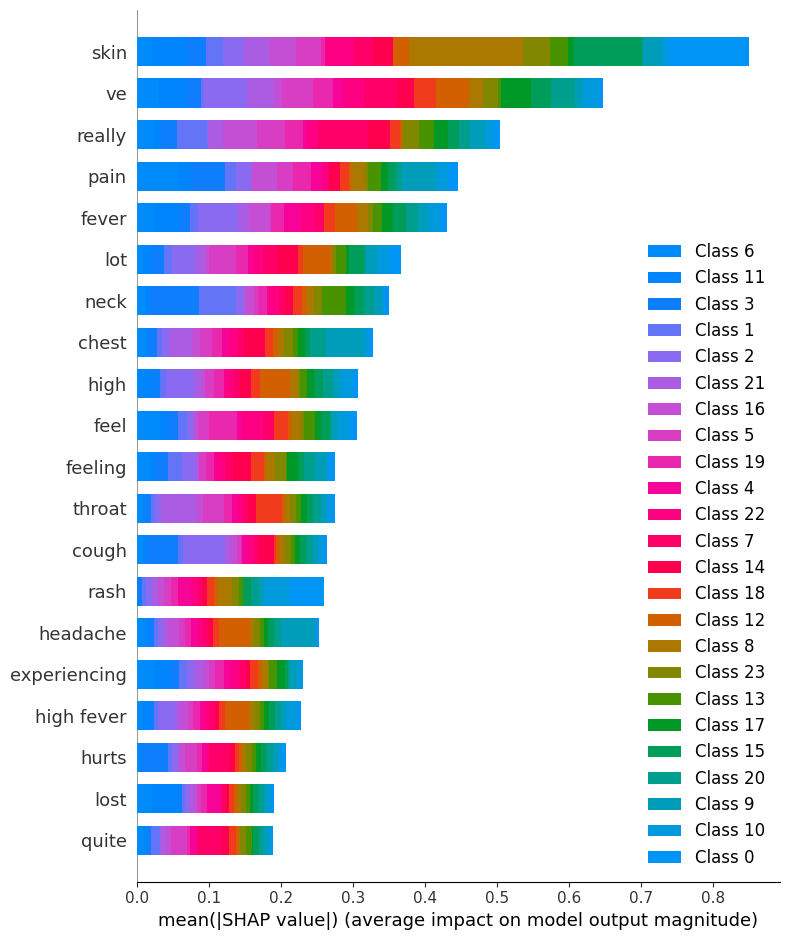

In [98]:
shap.summary_plot(
    lr_shap_values,
    X_test_tfidf,
    feature_names=feature_names,
    max_display=20
)

### Interpretation

The global SHAP analysis identifies the TF-IDF features that have the
largest influence on the Logistic Regression disease predictions.

These features represent symptom-related words and phrases extracted
from the patient symptom descriptions.

A feature with a larger absolute SHAP value has a greater influence
on the model's prediction. The direction of the contribution depends
on the predicted disease class.

These results describe statistical associations learned from the
dataset and should not be interpreted as clinical causation.

In [100]:
sample_index = 0

print("Test sample index:", sample_index)
print("Original dataframe index:", X_test.index[sample_index])

Test sample index: 0
Original dataframe index: 408


In [101]:
original_index = X_test.index[sample_index]

print("Symptoms:")
print(df.loc[original_index, "text"])

print("\nActual Disease:")
print(df.loc[original_index, "label"])

Symptoms:
I've been experiencing chills, feel really exhausted, and my cough just won't go away. When I cough, my chest aches and my heart is pounding. It's a disgusting brownish hue, the mucous I'm coming up.

Actual Disease:
Pneumonia


## Ensemble Prediction for the Selected Test Sample

The same test sample is passed through all three base classifiers.

The individual predictions are displayed along with the final Weighted
Soft Voting prediction.

The ensemble combines the probability distributions of the three models
using weights of 2, 2, and 1 for Logistic Regression, Random Forest,
and XGBoost respectively.

In [102]:
# Predictions from individual models

lr_sample_prediction = lr_probabilities[sample_index].argmax()

rf_sample_prediction = rf_probabilities[sample_index].argmax()

xgb_sample_prediction = xgb_probabilities[sample_index].argmax()

# Final weighted ensemble prediction

ensemble_sample_prediction = y_pred_weighted[sample_index]

print("Logistic Regression:",
      label_encoder.inverse_transform([lr_sample_prediction])[0])

print("Random Forest:",
      label_encoder.inverse_transform([rf_sample_prediction])[0])

print("XGBoost:",
      label_encoder.inverse_transform([xgb_sample_prediction])[0])

print("\nFinal Weighted Ensemble:",
      label_encoder.inverse_transform([ensemble_sample_prediction])[0])

Logistic Regression: Pneumonia
Random Forest: Pneumonia
XGBoost: Pneumonia

Final Weighted Ensemble: Pneumonia


In [103]:
actual_sample_prediction = y_test_encoded[sample_index]

print("\nActual Disease:",
      label_encoder.inverse_transform([actual_sample_prediction])[0])


Actual Disease: Pneumonia


In [104]:
# Weighted probabilities for the selected sample

sample_weighted_probabilities = weighted_probabilities[sample_index]

weighted_probability_table = pd.DataFrame({
    "Disease": label_encoder.classes_,
    "Weighted Probability": sample_weighted_probabilities
})

weighted_probability_table = (
    weighted_probability_table
    .sort_values(
        "Weighted Probability",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    weighted_probability_table.head(10).round(4)
)

,Disease,Weighted Probability
0,Pneumonia,0.4811
1,Bronchial Asthma,0.0721
2,Common Cold,0.0469
3,Typhoid,0.0351
4,drug reaction,0.0310
5,Cervical spondylosis,0.0303
6,diabetes,0.0300
7,allergy,0.0281
8,Malaria,0.0267
9,Hypertension,0.0257


In [105]:
# Get SHAP values for the selected sample

sample_shap_values = lr_shap_values[sample_index]

print("SHAP value shape:", sample_shap_values.values.shape)

SHAP value shape: (5000, 24)


In [106]:
predicted_class = lr_sample_prediction

sample_shap_class = sample_shap_values[:, predicted_class]

print(
    "Explaining class:",
    label_encoder.inverse_transform([predicted_class])[0]
)

Explaining class: Pneumonia


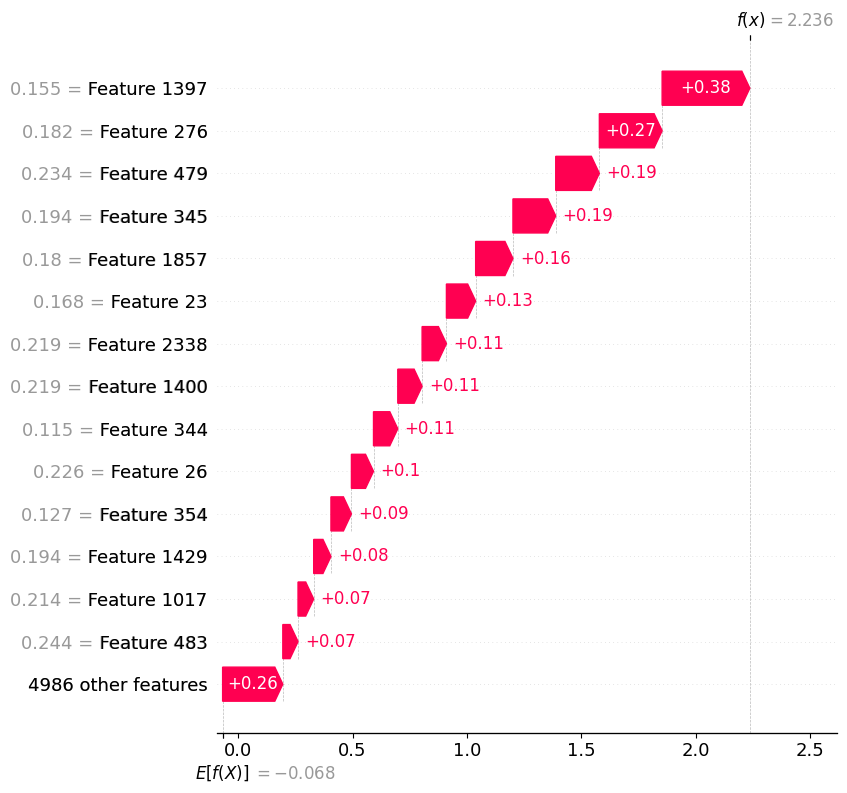

In [107]:
shap.plots.waterfall(
    sample_shap_class,
    max_display=15
)

Explaining class: Pneumonia
Explanation shape: (5000,)


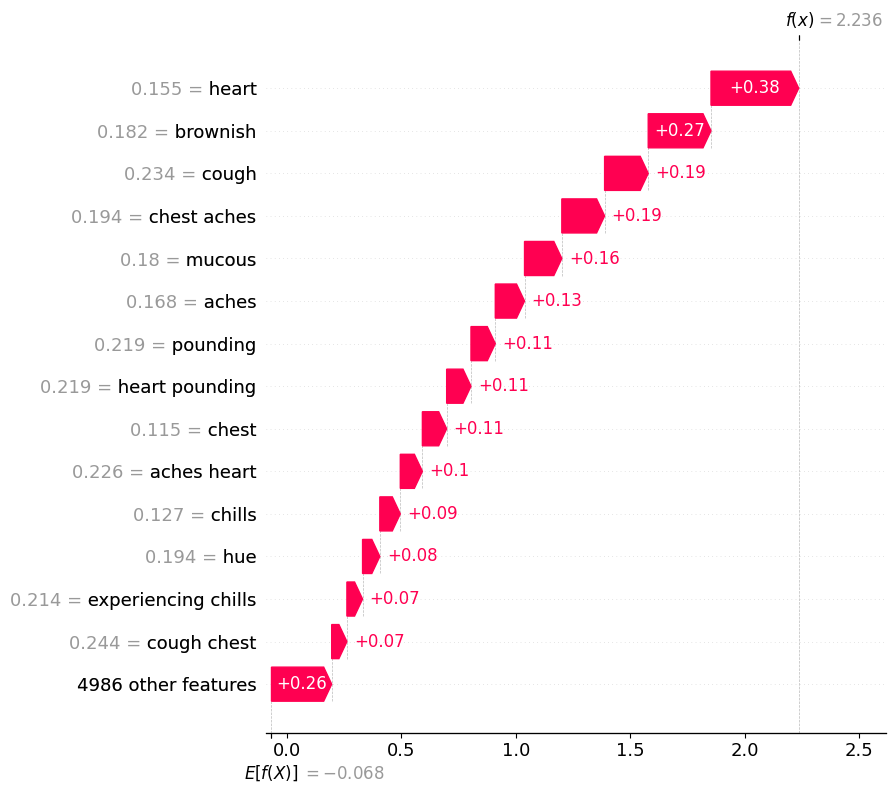

In [111]:
# Get the Logistic Regression predicted class
predicted_class = lr_sample_prediction

print(
    "Explaining class:",
    label_encoder.inverse_transform([predicted_class])[0]
)

# Select SHAP explanation for the predicted class
sample_shap_class = sample_shap_values[:, predicted_class]

# Get the actual TF-IDF feature names
feature_names = tfidf.get_feature_names_out()

# Get the actual TF-IDF values for this test sample
sample_data = X_test_tfidf[sample_index].toarray().flatten()

# Create a new SHAP Explanation with feature names
sample_explanation = shap.Explanation(
    values=sample_shap_class.values,
    base_values=sample_shap_class.base_values,
    data=sample_data,
    feature_names=feature_names
)

print("Explanation shape:", sample_explanation.values.shape)

# Plot
shap.plots.waterfall(
    sample_explanation,
    max_display=15
)

In [112]:
print("Patient symptoms:")
print(df.loc[original_index, "text"])

print("\nActual disease:")
print(df.loc[original_index, "label"])

print("\nLogistic Regression prediction:")
print(
    label_encoder.inverse_transform(
        [lr_sample_prediction]
    )[0]
)

print("\nWeighted Ensemble prediction:")
print(
    label_encoder.inverse_transform(
        [ensemble_sample_prediction]
    )[0]
)

Patient symptoms:
I've been experiencing chills, feel really exhausted, and my cough just won't go away. When I cough, my chest aches and my heart is pounding. It's a disgusting brownish hue, the mucous I'm coming up.

Actual disease:
Pneumonia

Logistic Regression prediction:
Pneumonia

Weighted Ensemble prediction:
Pneumonia


## Local SHAP Interpretation

The local SHAP explanation shows how individual TF-IDF features
influence the Logistic Regression prediction for a single patient.

The features with the largest positive SHAP contributions provide the
strongest support for the disease class being explained. In this
example, terms such as cough, chest aches, mucous, chills, and related
symptom terms contribute positively to the model output.

The SHAP values represent learned statistical associations within the
dataset. They do not imply that an individual symptom clinically
causes or confirms a disease.

The final prediction used by the application is produced by the
Weighted Soft Voting ensemble, while SHAP is used to provide a
feature-level explanation of the Logistic Regression component.

#  Ethics and Responsible AI

The proposed disease prediction system is intended as a machine-learning
decision-support system and not as an autonomous medical diagnostic system.

The model predicts a disease class from a patient's symptom description.
The prediction should be interpreted as an indication of the most likely
class according to the training data and should not replace professional
medical evaluation.

##  Bias and Fairness

The dataset used in this project is balanced across the disease classes,
which reduces class-imbalance bias during model training.

However, balanced class frequencies do not guarantee complete fairness.
The dataset may not represent the full diversity of real-world patients,
including differences in age, gender, language, symptom descriptions,
medical history, geographic populations, and disease prevalence.

Therefore, the model's performance on this dataset should not be assumed
to represent performance across all real-world demographic or clinical
groups.

Future work should evaluate the model on larger and more diverse clinical
datasets and perform subgroup-based fairness analysis where appropriate.

##  Privacy

The dataset used for this project does not require personally identifiable
patient information for making predictions.

In a real-world deployment, the system should follow data-minimization
principles and collect only information necessary for prediction.

Personally identifiable information such as names, phone numbers, addresses,
hospital identification numbers, or other unnecessary personal information
should not be included in the model input.

Any future clinical deployment would require appropriate privacy,
security, consent, and data-governance mechanisms.

##  Prediction Uncertainty

The model produces a probability distribution across the disease classes.
These probabilities indicate the model's relative confidence based on the
patterns learned from the training data.

However, model probability should not automatically be interpreted as
clinical probability.

For example, a prediction such as:

Pneumonia = 0.48

does not mean that the patient has a 48% medical probability of having
pneumonia.

The output should instead be interpreted as the model's relative prediction
confidence among the available disease classes.

##  False-Positive and False-Negative Costs

Both false-positive and false-negative predictions are important in a
health-related machine-learning application.

### False Positive

A false positive occurs when the model predicts a disease that is not
actually present.

Example:

Actual Disease: Common Cold
Predicted Disease: Pneumonia

A false positive may result in unnecessary concern, testing, referral,
or additional healthcare resources.

### False Negative

A false negative occurs when the model fails to predict a disease that
is actually present.

Example:

Actual Disease: Pneumonia
Predicted Disease: Common Cold

A false negative can potentially result in delayed medical attention.

The severity of these errors depends on the disease and the clinical
context. Therefore, the system should not make autonomous treatment or
diagnostic decisions.

##  Human Oversight

The proposed system follows a human-in-the-loop approach.

The intended workflow is:

Patient Symptoms
        ↓
Machine Learning Prediction
        ↓
Predicted Disease + Model Confidence
        ↓
Healthcare Professional Review
        ↓
Clinical Assessment and Decision

The machine-learning model should assist healthcare professionals rather
than replace them.

A healthcare professional should consider additional information such as
medical history, physical examination, laboratory results, imaging, and
other clinical evidence before making a final diagnosis.

##  Deployment Limitations

Several limitations must be considered before deploying this system in a
real-world healthcare environment:

1. The dataset is limited compared with real-world clinical populations.

2. The model has not undergone clinical validation.

3. Real patients may describe symptoms differently from the descriptions
   contained in the training dataset.

4. Disease prevalence in the real world may differ from the distribution
   represented in the dataset.

5. The model may perform differently on populations that are not
   sufficiently represented in the training data.

6. Model confidence does not represent confirmed medical diagnosis.

7. The system should not independently prescribe medication or treatment.

8. Predictions should be reviewed by an appropriately qualified
   healthcare professional.

Therefore, the current system should be considered a machine-learning
prototype for educational and decision-support purposes rather than a
clinically deployable diagnostic system.

##  Responsible AI Conclusion

The disease prediction system demonstrates how ensemble machine learning
and explainability techniques can be applied to a health-related prediction
problem.

However, high predictive performance alone is not sufficient for healthcare
deployment.

The system should provide transparent predictions, communicate uncertainty,
consider potential bias, protect user privacy, account for the consequences
of false predictions, and maintain human oversight.

SHAP explanations are used to improve interpretability by showing which
symptom features contributed to an individual prediction.

The final system is therefore designed as a decision-support prototype,
with professional medical judgment remaining essential for any real-world
clinical decision.

# 30. Final Model Selection

The evaluated models include a Logistic Regression baseline, Random Forest
bagging, XGBoost boosting, Soft Voting, Heterogeneous Stacking, and Weighted
Soft Voting.

Model selection is based primarily on F1-score and cross-validation F1-score,
while accuracy, precision, recall, and confusion matrices are also considered.

The purpose of this comparison is to identify:

1. The strongest individual model.
2. The strongest ensemble model.
3. The final model configuration to be used for the live prediction system.

In [118]:
# Identify the best individual model

individual_model_names = [
    "Logistic Regression",
    "Random Forest",
    "XGBoost"
]

individual_results = final_model_comparison[
    final_model_comparison["Model"].isin(individual_model_names)
]

best_individual_index = individual_results["CV F1-Score"].idxmax()

best_individual = individual_results.loc[best_individual_index]

print("Best Individual Model")
print("---------------------")
print("Model:", best_individual["Model"])
print("Test F1-Score:", best_individual["F1-Score"])
print("CV F1-Score:", best_individual["CV F1-Score"])

Best Individual Model
---------------------
Model: Logistic Regression
Test F1-Score: 0.9484581179627618
CV F1-Score: 0.9582968978189566


In [119]:
# Identify the best ensemble model

ensemble_model_names = [
    "Soft Voting Ensemble",
    "Heterogeneous Stacking",
    "Weighted Soft Voting"
]

ensemble_results = final_model_comparison[
    final_model_comparison["Model"].isin(ensemble_model_names)
]

best_ensemble_index = ensemble_results["CV F1-Score"].idxmax()

best_ensemble = ensemble_results.loc[best_ensemble_index]

print("Best Ensemble Model")
print("-------------------")
print("Model:", best_ensemble["Model"])
print("Test F1-Score:", best_ensemble["F1-Score"])
print("CV F1-Score:", best_ensemble["CV F1-Score"])

Best Ensemble Model
-------------------
Model: Weighted Soft Voting
Test F1-Score: 0.9205554978503894
CV F1-Score: 0.9388020910118435


In [120]:
display(
    final_model_comparison.round(4)
)

,Model,Accuracy,Precision,Recall,F1-Score,CV F1-Score
0,Logistic Regression,0.9500,0.9522,0.9500,0.9485,0.9583
1,Random Forest,0.9500,0.9521,0.9500,0.9489,0.9453
2,XGBoost,0.8500,0.8722,0.8500,0.8508,0.8877
3,Soft Voting Ensemble,0.9042,0.9126,0.9042,0.9036,0.9299
4,Heterogeneous Stacking,0.9000,0.9121,0.9000,0.9009,0.9287
5,Weighted Soft Voting,0.9208,0.9328,0.9208,0.9206,0.9388


# 31. Final Live Prediction Demonstration

A realistic synthetic patient record is used to demonstrate the complete
prediction pipeline.

The symptom description is transformed using the previously fitted TF-IDF
vectorizer and passed to the three trained base models:

- Logistic Regression
- Random Forest
- XGBoost

Their probability outputs are combined using the previously selected
Weighted Soft Voting mechanism.

The final predicted disease and probability distribution are then displayed.

In [121]:
synthetic_symptoms = """
persistent cough, chest pain, shortness of breath,
fever, fatigue and mucus
"""

print("Synthetic Patient Symptoms:")
print(synthetic_symptoms)

Synthetic Patient Symptoms:

persistent cough, chest pain, shortness of breath,
fever, fatigue and mucus



In [122]:
synthetic_tfidf = tfidf.transform(
    [synthetic_symptoms]
)

print("Processed synthetic sample shape:")
print(synthetic_tfidf.shape)

print(
    "Number of non-zero TF-IDF features:",
    synthetic_tfidf.nnz
)

Processed synthetic sample shape:
(1, 5000)
Number of non-zero TF-IDF features: 14


In [123]:
# Logistic Regression
synthetic_lr_prob = baseline_model.predict_proba(
    synthetic_tfidf
)[0]

synthetic_lr_prediction = np.argmax(
    synthetic_lr_prob
)


# Random Forest
synthetic_rf_prob = rf_model.predict_proba(
    synthetic_tfidf
)[0]

synthetic_rf_prediction = np.argmax(
    synthetic_rf_prob
)


# XGBoost
synthetic_xgb_prob = xgb_model.predict_proba(
    synthetic_tfidf
)[0]

synthetic_xgb_prediction = np.argmax(
    synthetic_xgb_prob
)

In [124]:
print("Individual Model Predictions")
print("----------------------------")

print(
    "Logistic Regression:",
    label_encoder.inverse_transform(
        [synthetic_lr_prediction]
    )[0]
)

print(
    "Random Forest:",
    label_encoder.inverse_transform(
        [synthetic_rf_prediction]
    )[0]
)

print(
    "XGBoost:",
    label_encoder.inverse_transform(
        [synthetic_xgb_prediction]
    )[0]
)

Individual Model Predictions
----------------------------
Logistic Regression: Bronchial Asthma
Random Forest: Bronchial Asthma
XGBoost: Hypertension


In [125]:
synthetic_weighted_probability = (
    2 * synthetic_lr_prob +
    2 * synthetic_rf_prob +
    1 * synthetic_xgb_prob
) / 5

In [126]:
synthetic_final_prediction = np.argmax(
    synthetic_weighted_probability
)

synthetic_final_disease = label_encoder.inverse_transform(
    [synthetic_final_prediction]
)[0]

print("Final Ensemble Prediction:")
print(synthetic_final_disease)

Final Ensemble Prediction:
Hypertension


In [127]:
synthetic_probability_table = pd.DataFrame({
    "Disease": label_encoder.classes_,
    "Weighted Probability": synthetic_weighted_probability
})

synthetic_probability_table = (
    synthetic_probability_table
    .sort_values(
        "Weighted Probability",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    synthetic_probability_table.head(10).round(4)
)

,Disease,Weighted Probability
0,Hypertension,0.2657
1,Bronchial Asthma,0.1592
2,drug reaction,0.0700
3,Pneumonia,0.0575
4,gastroesophageal reflux disease,0.0563
5,Cervical spondylosis,0.0526
6,Dengue,0.0414
7,Typhoid,0.0388
8,allergy,0.0339
9,urinary tract infection,0.0286


# 32. Local Explanation of the Synthetic Prediction

SHAP is used to explain the Logistic Regression component of the
ensemble because Logistic Regression is the strongest individual
classifier based on cross-validation performance.

For the synthetic patient, the Weighted Soft Voting ensemble produces
the final disease prediction, while SHAP explains which TF-IDF symptom
features influenced the Logistic Regression prediction.

The SHAP explanation should therefore be interpreted as an explanation
of the Logistic Regression component rather than a direct explanation
of the complete ensemble.

In [128]:
synthetic_shap_values = lr_explainer(
    synthetic_tfidf
)

print("SHAP output shape:")
print(synthetic_shap_values.values.shape)

SHAP output shape:
(1, 5000, 24)


In [129]:
synthetic_lr_class = synthetic_lr_prediction

print(
    "Explaining Logistic Regression class:"
)

print(
    label_encoder.inverse_transform(
        [synthetic_lr_class]
    )[0]
)

Explaining Logistic Regression class:
Bronchial Asthma


In [130]:
synthetic_shap_class = synthetic_shap_values[
    :, synthetic_lr_class
]

print(
    "Selected SHAP shape:",
    synthetic_shap_class.shape
)

Selected SHAP shape: (1, 24)


In [131]:
synthetic_feature_names = tfidf.get_feature_names_out()

synthetic_data = (
    synthetic_tfidf
    .toarray()
    .flatten()
)

In [132]:
synthetic_explanation = shap.Explanation(
    values=synthetic_shap_class.values,
    base_values=synthetic_shap_class.base_values,
    data=synthetic_data,
    feature_names=synthetic_feature_names
)

In [135]:
# Select the synthetic patient's explanation
# and the Logistic Regression predicted class

synthetic_single_shap = synthetic_shap_values[
    0, :, synthetic_lr_class
]

print("Selected SHAP shape:")
print(synthetic_single_shap.shape)

Selected SHAP shape:
(5000,)


In [136]:
synthetic_explanation = shap.Explanation(
    values=synthetic_single_shap.values,
    base_values=synthetic_single_shap.base_values,
    data=synthetic_tfidf.toarray()[0],
    feature_names=tfidf.get_feature_names_out()
)

print("Explanation shape:")
print(synthetic_explanation.values.shape)

Explanation shape:
(5000,)


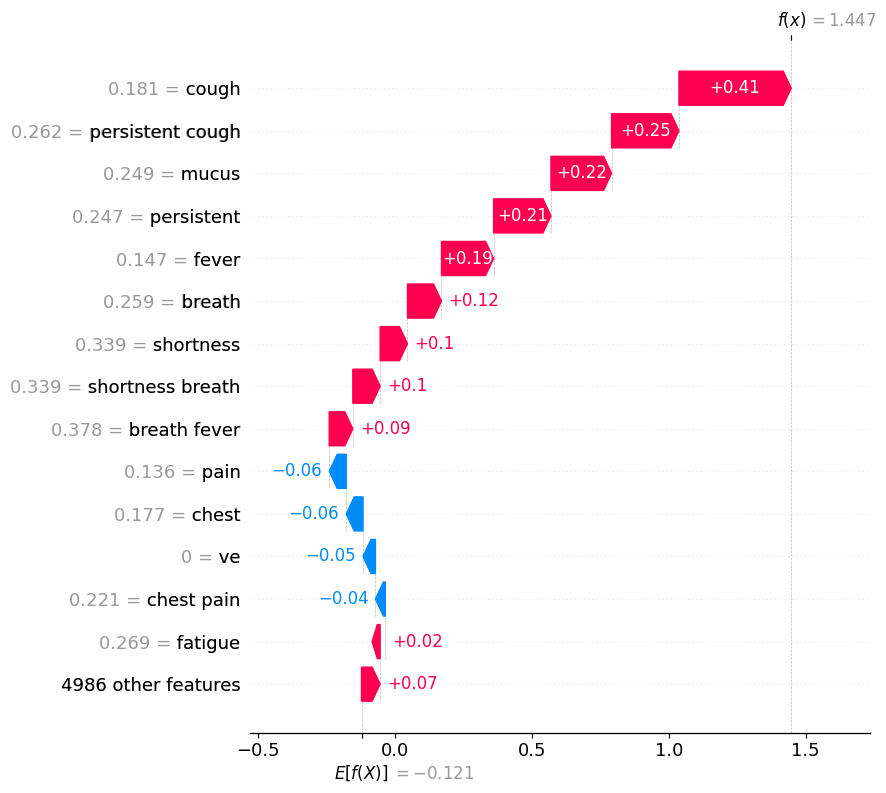

In [137]:
shap.plots.waterfall(
    synthetic_explanation,
    max_display=15
)

In [138]:
synthetic_shap_table = pd.DataFrame({
    "Feature": synthetic_feature_names,
    "TF-IDF Value": synthetic_data,
    "SHAP Value": synthetic_explanation.values
})

synthetic_shap_table["Absolute SHAP"] = (
    synthetic_shap_table["SHAP Value"].abs()
)

synthetic_shap_table = (
    synthetic_shap_table
    .sort_values(
        "Absolute SHAP",
        ascending=False
    )
    .head(15)
    .reset_index(drop=True)
)

display(
    synthetic_shap_table.round(4)
)

,Feature,TF-IDF Value,SHAP Value,Absolute SHAP
0,cough,0.1810,0.4098,0.4098
1,persistent cough,0.2617,0.2460,0.2460
2,mucus,0.2493,0.2212,0.2212
3,persistent,0.2474,0.2094,0.2094
4,fever,0.1474,0.1902,0.1902
5,breath,0.2594,0.1241,0.1241
6,shortness,0.3391,0.0997,0.0997
7,shortness breath,0.3391,0.0997,0.0997
8,breath fever,0.3778,0.0861,0.0861
9,pain,0.1356,-0.0621,0.0621


# 33. Final Results and Visualizations

The performance of all trained models and ensemble methods is compared
using the evaluation metrics obtained on the untouched test set.

The comparison includes Accuracy, Precision, Recall, F1-Score, and
5-Fold Cross-Validation F1-Score.

In [139]:
# Final model comparison

display(
    final_model_comparison
    .sort_values("F1-Score", ascending=False)
    .round(4)
)

,Model,Accuracy,Precision,Recall,F1-Score,CV F1-Score
1,Random Forest,0.9500,0.9521,0.9500,0.9489,0.9453
0,Logistic Regression,0.9500,0.9522,0.9500,0.9485,0.9583
5,Weighted Soft Voting,0.9208,0.9328,0.9208,0.9206,0.9388
3,Soft Voting Ensemble,0.9042,0.9126,0.9042,0.9036,0.9299
4,Heterogeneous Stacking,0.9000,0.9121,0.9000,0.9009,0.9287
2,XGBoost,0.8500,0.8722,0.8500,0.8508,0.8877


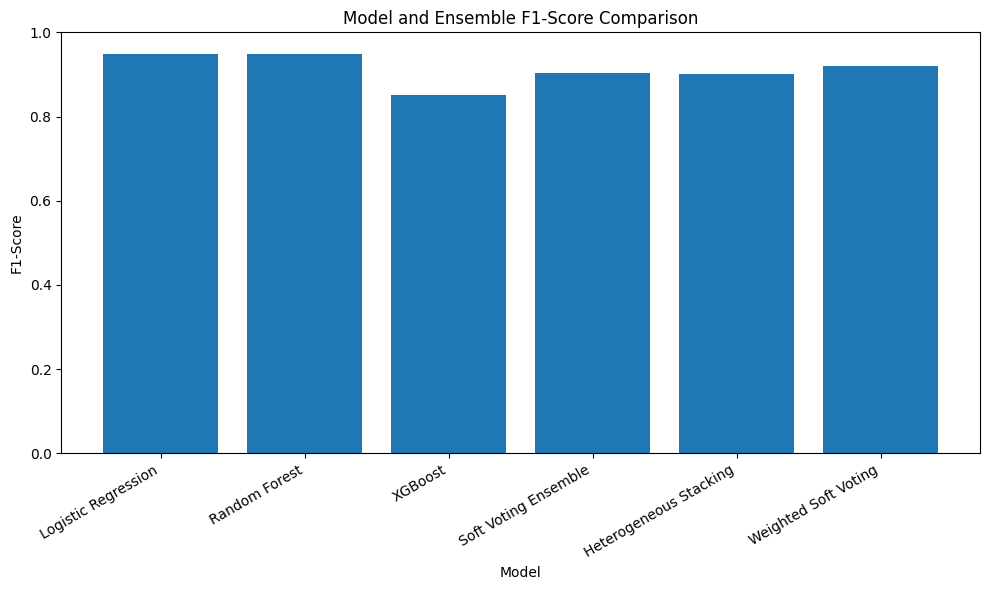

In [140]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.bar(
    final_model_comparison["Model"],
    final_model_comparison["F1-Score"]
)

plt.ylabel("F1-Score")
plt.xlabel("Model")
plt.title("Model and Ensemble F1-Score Comparison")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 1)

plt.tight_layout()
plt.show()

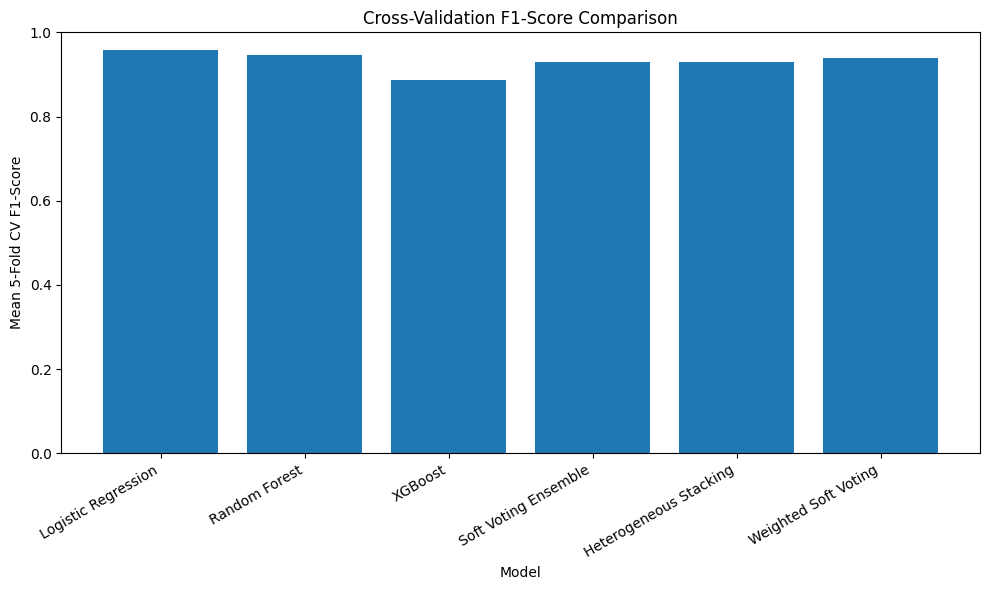

In [141]:
plt.figure(figsize=(10, 6))

cv_models = final_model_comparison[
    final_model_comparison["CV F1-Score"].notna()
]

plt.bar(
    cv_models["Model"],
    cv_models["CV F1-Score"]
)

plt.ylabel("Mean 5-Fold CV F1-Score")
plt.xlabel("Model")
plt.title("Cross-Validation F1-Score Comparison")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 1)

plt.tight_layout()
plt.show()

In [143]:
best_individual_f1 = final_model_comparison[
    final_model_comparison["Model"] == "Logistic Regression"
]["F1-Score"].iloc[0]

weighted_ensemble_f1 = final_model_comparison[
    final_model_comparison["Model"] == "Weighted Soft Voting"
]["F1-Score"].iloc[0]

print("Best Individual Model F1-Score:",
      round(best_individual_f1, 4))

print("Weighted Soft Voting F1-Score:",
      round(weighted_ensemble_f1, 4))

difference = weighted_ensemble_f1 - best_individual_f1

print("Difference:",
      round(difference, 4))

Best Individual Model F1-Score: 0.9485
Weighted Soft Voting F1-Score: 0.9206
Difference: -0.0279


In [144]:
print("Checking trained ML components...\n")

objects_to_check = {
    "TF-IDF Vectorizer": "tfidf",
    "Label Encoder": "label_encoder",
    "Logistic Regression": "baseline_model",
    "Random Forest": "rf_model",
    "XGBoost": "xgb_model",
    "Weighted Voting Model": "weighted_voting_model"
}

for name, variable in objects_to_check.items():
    print(f"{name:25}:", "Available" if variable in globals() else "NOT FOUND")

Checking trained ML components...

TF-IDF Vectorizer        : Available
Label Encoder            : Available
Logistic Regression      : Available
Random Forest            : Available
XGBoost                  : Available
Weighted Voting Model    : Available


# Streamlit Application Preparation

The trained machine learning components are exported from the notebook so
that the Streamlit application can load the already-trained models without
retraining them.

The exported components include:

- TF-IDF vectorizer
- Label encoder
- Logistic Regression model
- Random Forest model
- XGBoost model

The final ensemble uses the previously established weights:

- Logistic Regression: 2
- Random Forest: 2
- XGBoost: 1

In [145]:
import os
import joblib

# Create directory for deployment models
os.makedirs("streamlit_models", exist_ok=True)

# Save preprocessing objects
joblib.dump(tfidf, "streamlit_models/tfidf_vectorizer.pkl")
joblib.dump(label_encoder, "streamlit_models/label_encoder.pkl")

# Save trained models
joblib.dump(baseline_model, "streamlit_models/logistic_regression.pkl")
joblib.dump(rf_model, "streamlit_models/random_forest.pkl")
joblib.dump(xgb_model, "streamlit_models/xgboost.pkl")

print("All deployment models saved successfully.")

All deployment models saved successfully.


In [146]:
import os

print("\nSaved deployment files:")

for file in sorted(os.listdir("streamlit_models")):
    print("✓", file)


Saved deployment files:
✓ label_encoder.pkl
✓ logistic_regression.pkl
✓ random_forest.pkl
✓ tfidf_vectorizer.pkl
✓ xgboost.pkl


In [147]:
loaded_tfidf = joblib.load(
    "streamlit_models/tfidf_vectorizer.pkl"
)

loaded_label_encoder = joblib.load(
    "streamlit_models/label_encoder.pkl"
)

loaded_lr = joblib.load(
    "streamlit_models/logistic_regression.pkl"
)

loaded_rf = joblib.load(
    "streamlit_models/random_forest.pkl"
)

loaded_xgb = joblib.load(
    "streamlit_models/xgboost.pkl"
)

print("All exported models loaded successfully.")

All exported models loaded successfully.


In [148]:
test_symptoms = (
    "cough fever fatigue shortness of breath chest pain"
)

test_vector = loaded_tfidf.transform(
    [test_symptoms]
)

lr_prob = loaded_lr.predict_proba(test_vector)[0]
rf_prob = loaded_rf.predict_proba(test_vector)[0]
xgb_prob = loaded_xgb.predict_proba(test_vector)[0]

weighted_prob = (
    2 * lr_prob +
    2 * rf_prob +
    1 * xgb_prob
) / 5

final_class = weighted_prob.argmax()

print("Test prediction:")
print(
    loaded_label_encoder.inverse_transform(
        [final_class]
    )[0]
)

Test prediction:
drug reaction


In [149]:
# Get the exact symptom vocabulary from the dataset

all_symptoms = set()

for text in df["text"]:
    symptoms = [s.strip() for s in text.split(",")]
    all_symptoms.update(symptoms)

symptom_options = sorted(all_symptoms)

print("Number of symptoms:", len(symptom_options))
print("\nSymptoms:")
print(symptom_options)

Number of symptoms: 2529

Symptoms:
['', 'A few days ago', 'A nasty rash has just appeared on my skin. Blackheads and pimples packed with pus are everywhere. Additionally', 'A rash has developed around my nose and lips', 'A rash that appears to be developing throughout my skin has been accompanying my recent bouts of intense itching and discomfort. On my skin', 'A skin rash with several pus-filled pimples and blackheads has been bothering me lately. Additionally', 'A sour', "Acidity and indigestion are among the digestive problems I've been having", 'After eating', 'All over my body', 'All over my body has been itching like crazy', 'Along with a change in taste and smell', 'Along with a chest pain and dizziness', 'Along with a chronic cough and limb weakness', 'Along with a headache', 'Along with a headache and chest pain', 'Along with a head\xa0pain', 'Along with a high fever', 'Along with a persistent cough', 'Along with a phlegmy cough and muscle weakness', 'Along with chest pain', 

In [150]:
print(df.head(10))
print("\nColumns:")
print(df.columns.tolist())

print("\nSample text values:")
for i, text in enumerate(df["text"].head(10)):
    print(f"{i}: {text}")

   Unnamed: 0      label  \
0           0  Psoriasis   
1           1  Psoriasis   
2           2  Psoriasis   
3           3  Psoriasis   
4           4  Psoriasis   
5           5  Psoriasis   
6           6  Psoriasis   
7           7  Psoriasis   
8           8  Psoriasis   
9           9  Psoriasis   

                                                                                                                                                    text  \
0          I have been experiencing a skin rash on my arms, legs, and torso for the past few weeks. It is red, itchy, and covered in dry, scaly patches.   
1             My skin has been peeling, especially on my knees, elbows, and scalp. This peeling is often accompanied by a burning or stinging sensation.   
2   I have been experiencing joint pain in my fingers, wrists, and knees. The pain is often achy and throbbing, and it gets worse when I move my joints.   
3  There is a silver like dusting on my skin, especially on my lowe

In [151]:
from collections import Counter
import re

# Combine all training descriptions
all_text = " ".join(df["text"].astype(str).tolist()).lower()

# Common symptom phrases that are already represented in the dataset
symptom_candidates = [
    "abdominal pain",
    "back pain",
    "chest pain",
    "chills",
    "constipation",
    "cough",
    "diarrhea",
    "dizziness",
    "fatigue",
    "fever",
    "headache",
    "heartburn",
    "indigestion",
    "itching",
    "joint pain",
    "muscle pain",
    "nausea",
    "nasal congestion",
    "runny nose",
    "rash",
    "shortness of breath",
    "sore throat",
    "stomach pain",
    "vomiting",
    "wheezing",
    "weakness",
    "weight loss",
    "weight gain",
    "loss of appetite",
    "increased appetite",
    "frequent urination",
    "painful urination",
    "blood in urine",
    "dark urine",
    "yellow skin",
    "blurred vision",
    "vision problems",
    "swelling",
    "skin peeling",
    "dry skin",
    "red skin",
    "scaly skin",
    "sweating",
    "mucus",
    "phlegm",
    "sneezing",
    "blocked nose",
    "difficulty swallowing",
    "bloating",
    "gas",
    "acid reflux",
    "burning sensation",
    "palpitations",
    "neck pain",
    "stiffness",
    "tremors",
    "balance problems",
    "memory problems",
    "difficulty concentrating",
    "sleep problems",
    "anxiety",
    "depression",
]

# Keep only symptoms that actually occur in the dataset
available_symptoms = [
    symptom
    for symptom in symptom_candidates
    if symptom in all_text
]

print("Number of available symptoms:", len(available_symptoms))
print("\nAvailable symptoms:\n")

for symptom in available_symptoms:
    print("-", symptom)

Number of available symptoms: 55

Available symptoms:

- abdominal pain
- back pain
- chest pain
- chills
- constipation
- cough
- diarrhea
- dizziness
- fatigue
- fever
- headache
- heartburn
- indigestion
- itching
- joint pain
- muscle pain
- nausea
- nasal congestion
- runny nose
- rash
- shortness of breath
- sore throat
- stomach pain
- vomiting
- wheezing
- weakness
- weight loss
- weight gain
- loss of appetite
- increased appetite
- frequent urination
- dark urine
- yellow skin
- blurred vision
- swelling
- skin peeling
- dry skin
- red skin
- sweating
- mucus
- phlegm
- sneezing
- blocked nose
- difficulty swallowing
- bloating
- gas
- acid reflux
- burning sensation
- palpitations
- neck pain
- stiffness
- tremors
- difficulty concentrating
- anxiety
- depression


In [152]:
test_symptoms = " ".join(available_symptoms)

test_vector = tfidf.transform([test_symptoms])

print("Input shape:", test_vector.shape)
print("Non-zero TF-IDF features:", test_vector.nnz)

Input shape: (1, 5000)
Non-zero TF-IDF features: 98


In [177]:
app_code = r'''
import streamlit as st
import joblib
import numpy as np
import pandas as pd

# ============================================================
# PAGE CONFIGURATION
# ============================================================

st.set_page_config(
    page_title="Care Match",
    page_icon="🩺",
    layout="wide"
)

# ============================================================
# LOAD TRAINED ML COMPONENTS
# ============================================================

tfidf = joblib.load(
    "streamlit_models/tfidf_vectorizer.pkl"
)

label_encoder = joblib.load(
    "streamlit_models/label_encoder.pkl"
)

lr_model = joblib.load(
    "streamlit_models/logistic_regression.pkl"
)

rf_model = joblib.load(
    "streamlit_models/random_forest.pkl"
)

xgb_model = joblib.load(
    "streamlit_models/xgboost.pkl"
)

# ============================================================
# LOAD REAL DOCTOR AND HOSPITAL DATASETS
# ============================================================

doctors = pd.read_csv(
    "bangalore_doctors_final.csv"
)

hospitals = pd.read_csv(
    "hospital_data_bangalore.csv"
)

# ============================================================
# DISEASE → DOCTOR SPECIALTY MAPPING
# ============================================================

DISEASE_SPECIALTY = {

    "Acne": "dermatologist",

    "Arthritis": "rheumatologist",

    "Bronchial Asthma": "pulmonologist",

    "Cervical spondylosis": "orthopedist",

    "Chicken pox": "dermatologist",

    "Common Cold": "general-physician",

    "Dengue": "general-physician",

    "Dimorphic Hemorrhoids": "surgeon",

    "Fungal infection": "dermatologist",

    "Hypertension": "cardiologist",

    "Impetigo": "dermatologist",

    "Jaundice": "gastroenterologist",

    "Malaria": "general-physician",

    "Migraine": "neurologist",

    "Pneumonia": "pulmonologist",

    "Psoriasis": "dermatologist",

    "Typhoid": "general-physician",

    "Varicose Veins": "vascular-surgeon",

    "allergy": "general-physician",

    "diabetes": "endocrinologist",

    "drug reaction": "general-physician",

    "gastroesophageal reflux disease": "gastroenterologist",

    "peptic ulcer disease": "gastroenterologist",

    "urinary tract infection": "urologist"
}

# ============================================================
# SYMPTOM VOCABULARY
# ============================================================

SYMPTOMS = [
    "abdominal pain",
    "back pain",
    "chest pain",
    "chills",
    "constipation",
    "cough",
    "diarrhea",
    "dizziness",
    "fatigue",
    "fever",
    "headache",
    "heartburn",
    "indigestion",
    "itching",
    "joint pain",
    "muscle pain",
    "nausea",
    "nasal congestion",
    "runny nose",
    "rash",
    "shortness of breath",
    "sore throat",
    "stomach pain",
    "vomiting",
    "wheezing",
    "weakness",
    "weight loss",
    "weight gain",
    "loss of appetite",
    "increased appetite",
    "frequent urination",
    "painful urination",
    "blood in urine",
    "dark urine",
    "yellow skin",
    "blurred vision",
    "vision problems",
    "swelling",
    "skin peeling",
    "dry skin",
    "red skin",
    "scaly skin",
    "sweating",
    "mucus",
    "phlegm",
    "sneezing",
    "blocked nose",
    "difficulty swallowing",
    "bloating",
    "gas",
    "acid reflux",
    "burning sensation",
    "palpitations",
    "neck pain",
    "stiffness",
    "tremors",
    "balance problems",
    "memory problems",
    "difficulty concentrating",
    "sleep problems",
    "anxiety",
    "depression"
]

# ============================================================
# HEADER
# ============================================================

st.title("🩺 Care Match")

st.subheader(
    "AI-Powered Symptom-Based Disease Prediction"
)

st.write(
    "Select the symptoms you are experiencing. "
    "The selected symptoms will be processed by the "
    "trained machine-learning models."
)

st.divider()

# ============================================================
# SYMPTOM SELECTION
# ============================================================

selected_symptoms = st.multiselect(
    "Select your symptoms:",
    options=SYMPTOMS,
    help="You can select multiple symptoms."
)

# ============================================================
# PREDICTION
# ============================================================

if st.button(
    "Predict Disease",
    type="primary"
):

    if len(selected_symptoms) == 0:

        st.warning(
            "Please select at least one symptom."
        )

    else:

        # ----------------------------------------------------
        # Convert selected symptoms to text
        # ----------------------------------------------------

        symptom_text = " ".join(
            selected_symptoms
        )

        # ----------------------------------------------------
        # TF-IDF transformation
        # ----------------------------------------------------

        X_input = tfidf.transform(
            [symptom_text]
        )

        # ----------------------------------------------------
        # Individual model probabilities
        # ----------------------------------------------------

        lr_prob = lr_model.predict_proba(
            X_input
        )[0]

        rf_prob = rf_model.predict_proba(
            X_input
        )[0]

        xgb_prob = xgb_model.predict_proba(
            X_input
        )[0]

        # ----------------------------------------------------
        # Individual predictions
        # ----------------------------------------------------

        lr_prediction = np.argmax(
            lr_prob
        )

        rf_prediction = np.argmax(
            rf_prob
        )

        xgb_prediction = np.argmax(
            xgb_prob
        )

        # ----------------------------------------------------
        # WEIGHTED SOFT VOTING
        #
        # Logistic Regression = 2
        # Random Forest       = 2
        # XGBoost             = 1
        # ----------------------------------------------------

        weighted_probability = (
            2 * lr_prob +
            2 * rf_prob +
            1 * xgb_prob
        ) / 5

        final_prediction = np.argmax(
            weighted_probability
        )

        final_disease = (
            label_encoder.inverse_transform(
                [final_prediction]
            )[0]
        )

        final_probability = (
            weighted_probability[
                final_prediction
            ] * 100
        )

        # ====================================================
        # SELECTED SYMPTOMS
        # ====================================================

        st.divider()

        st.subheader(
            "Selected Symptoms"
        )

        st.write(
            ", ".join(selected_symptoms)
        )

        # ====================================================
        # INDIVIDUAL MODEL PREDICTIONS
        # ====================================================

        st.subheader(
            "Individual Model Predictions"
        )

        prediction_data = pd.DataFrame({

            "Model": [
                "Logistic Regression",
                "Random Forest",
                "XGBoost"
            ],

            "Prediction": [

                label_encoder.inverse_transform(
                    [lr_prediction]
                )[0],

                label_encoder.inverse_transform(
                    [rf_prediction]
                )[0],

                label_encoder.inverse_transform(
                    [xgb_prediction]
                )[0]
            ]
        })

        st.dataframe(
            prediction_data,
            hide_index=True,
            use_container_width=True
        )

        # ====================================================
        # FINAL ENSEMBLE PREDICTION
        # ====================================================

        st.subheader(
            "Final Ensemble Prediction"
        )

        st.success(
            f"Predicted Disease: {final_disease}"
        )

        st.metric(
            "Weighted Model Probability",
            f"{final_probability:.2f}%"
        )

        # ====================================================
        # TOP DISEASE PREDICTIONS
        # ====================================================

        st.subheader(
            "Top Disease Predictions"
        )

        probability_table = pd.DataFrame({

            "Disease":
                label_encoder.classes_,

            "Weighted Probability":
                weighted_probability
        })

        probability_table = (
            probability_table
            .sort_values(
                "Weighted Probability",
                ascending=False
            )
            .head(10)
            .reset_index(drop=True)
        )

        probability_table[
            "Weighted Probability"
        ] = (
            probability_table[
                "Weighted Probability"
            ] * 100
        ).round(2)

        st.dataframe(
            probability_table,
            hide_index=True,
            use_container_width=True
        )

        # ====================================================
        # DOCTOR RECOMMENDATION
        # ====================================================

        st.divider()

        st.header(
            "👨‍⚕️ Doctor Recommendation"
        )

        recommended_specialty = (
            DISEASE_SPECIALTY.get(
                final_disease
            )
        )

        if recommended_specialty:

            st.write(
                f"Recommended specialty: "
                f"**{recommended_specialty.replace('-', ' ').title()}**"
            )

            matching_doctors = doctors[
                doctors["specialty"].str.lower()
                == recommended_specialty.lower()
            ].copy()

            if len(matching_doctors) > 0:

                # --------------------------------------------
                # Rank doctors
                # --------------------------------------------

                matching_doctors = (
                    matching_doctors
                    .sort_values(
                        by=[
                            "rating",
                            "experience_years"
                        ],
                        ascending=[
                            False,
                            False
                        ]
                    )
                    .head(3)
                )

                st.write(
                    f"Top {len(matching_doctors)} "
                    f"matching doctors:"
                )

                for _, doctor in (
                    matching_doctors.iterrows()
                ):

                    with st.container(
                        border=True
                    ):

                        st.subheader(
                            doctor["name"]
                        )

                        st.write(
                            f"**Specialty:** "
                            f"{doctor['specialty'].replace('-', ' ').title()}"
                        )

                        st.write(
                            f"**Degree:** "
                            f"{doctor['degree']}"
                        )

                        st.write(
                            f"**Experience:** "
                            f"{doctor['experience_years']} years"
                        )

                        st.write(
                            f"**Rating:** ⭐ "
                            f"{doctor['rating']}"
                        )

                        st.write(
                            f"**Consultation Fee:** "
                            f"₹{doctor['consultation_fee']}"
                        )

                        st.write(
                            f"**Location:** "
                            f"{doctor['bangalore_location']}"
                        )

                        if pd.notna(
                            doctor["google_maps_link"]
                        ):

                            st.link_button(
                                "📍 View on Google Maps",
                                doctor[
                                    "google_maps_link"
                                ]
                            )

            else:

                st.info(
                    "No doctors were found for "
                    "the recommended specialty."
                )

        # ====================================================
            # HOSPITAL RECOMMENDATION
            # ====================================================

            st.divider()

            st.header(
                "🏥 Hospital Recommendation"
            )

            st.info(
                "Hospital recommendations are based on "
                "the available Bangalore hospital dataset. "
                "The dataset does not contain disease-specific "
                "hospital specialties, so hospitals are ranked "
                "using rating and number of ratings rather than "
                "claiming disease-specific specialization."
            )

            # ----------------------------------------------------
            # Convert number-of-ratings to numeric score
            # ----------------------------------------------------

            hospital_display = hospitals.copy()

            def parse_rating_count(value):

                if pd.isna(value):
                    return 0

                value = str(value)

                # Remove quotes, parentheses and spaces
                value = (
                    value
                    .replace("'", "")
                    .replace("(", "")
                    .replace(")", "")
                    .replace(",", "")
                    .strip()
                )

                # Values such as 8.6T
                if value.lower().endswith("t"):

                    try:
                        return float(
                            value[:-1]
                        ) * 1000

                    except:
                        return 0

                try:
                    return float(value)

                except:
                    return 0

            hospital_display[
                "rating_count_numeric"
            ] = hospital_display[
                "No_of_people_rated"
            ].apply(
                parse_rating_count
            )

           # ====================================================
    # HOSPITAL RECOMMENDATION
    # ====================================================

    st.divider()

    st.header("🏥 Hospital Recommendation")

    # ====================================================
    # DISEASE-SPECIFIC HOSPITAL KEYWORDS
    # ====================================================

    DISEASE_HOSPITAL_KEYWORDS = {

        "Acne": [
            "dermatology",
            "skin",
            "dermatologist"
        ],

        "Arthritis": [
            "orthopedic",
            "orthopaedic",
            "rheumatology",
            "rheumatologist",
            "joint"
        ],

        "Bronchial Asthma": [
            "pulmonology",
            "pulmonary",
            "respiratory",
            "chest",
            "lung"
        ],

        "Cervical spondylosis": [
            "orthopedic",
            "orthopaedic",
            "spine",
            "neurology"
        ],

        "Chicken pox": [
            "dermatology",
            "skin",
            "general physician",
            "general medicine"
        ],

        "Common Cold": [
            "general physician",
            "general medicine",
            "internal medicine"
        ],

        "Dengue": [
            "general physician",
            "general medicine",
            "infectious",
            "internal medicine"
        ],

        "Dimorphic Hemorrhoids": [
            "proctology",
            "colorectal",
            "general surgery",
            "surgery"
        ],

        "Fungal infection": [
            "dermatology",
            "skin"
        ],

        "Hypertension": [
            "cardiology",
            "cardiac",
            "heart",
            "hypertension",
            "cardiovascular",
            "vascular",
            "general medicine"
        ],

        "Impetigo": [
            "dermatology",
            "skin"
        ],

        "Jaundice": [
            "gastroenterology",
            "gastro",
            "liver",
            "hepatology"
        ],

        "Malaria": [
            "general physician",
            "general medicine",
            "infectious",
            "internal medicine"
        ],

        "Migraine": [
            "neurology",
            "neurologist",
            "neurosurgery"
        ],

        "Pneumonia": [
            "pulmonology",
            "pulmonary",
            "respiratory",
            "chest",
            "lung"
        ],

        "Psoriasis": [
            "dermatology",
            "skin"
        ],

        "Typhoid": [
            "general physician",
            "general medicine",
            "infectious",
            "internal medicine"
        ],

        "Varicose Veins": [
            "vascular",
            "vascular surgery",
            "vein",
            "cardiovascular"
        ],

        "allergy": [
            "allergy",
            "immunology",
            "general physician",
            "general medicine"
        ],

        "diabetes": [
            "diabetes",
            "endocrinology",
            "endocrine",
            "general medicine"
        ],

        "drug reaction": [
            "dermatology",
            "skin",
            "allergy",
            "immunology",
            "general medicine",
            "general physician",
            "internal medicine"
        ],

        "gastroesophageal reflux disease": [
            "gastroenterology",
            "gastro",
            "digestive"
        ],

        "peptic ulcer disease": [
            "gastroenterology",
            "gastro",
            "digestive",
            "general surgery"
        ],

        "urinary tract infection": [
            "urology",
            "urologist",
            "kidney",
            "urinary"
        ]
    }


    # ====================================================
    # CLEAN HOSPITAL DATA
    # ====================================================

    hospital_display = hospitals.copy()

    # Convert important fields to strings
    hospital_display["Hospital_name"] = (
        hospital_display["Hospital_name"]
        .fillna("")
        .astype(str)
    )

    hospital_display["Type"] = (
        hospital_display["Type"]
        .fillna("")
        .astype(str)
    )

    hospital_display["Address"] = (
        hospital_display["Address"]
        .fillna("")
        .astype(str)
    )

    hospital_display["Highlighted_review"] = (
        hospital_display["Highlighted_review"]
        .fillna("")
        .astype(str)
    )

    # ====================================================
    # CLEAN RATING
    # ====================================================

    hospital_display["Rating_numeric"] = pd.to_numeric(
        hospital_display["Rating"],
        errors="coerce"
    )

    # Remove obviously invalid ratings
    hospital_display = hospital_display[
        hospital_display["Rating_numeric"].between(
            0,
            5
        )
    ].copy()


    # ====================================================
    # CLEAN NUMBER OF REVIEWS
    # ====================================================

    def parse_review_count(value):

        if pd.isna(value):
            return 0

        value = str(value)

        # Remove unwanted characters
        value = (
            value
            .replace("'", "")
            .replace('"', "")
            .replace("(", "")
            .replace(")", "")
            .replace(",", "")
            .strip()
        )

        if value == "":
            return 0

        # Handle values such as 8.6T
        if value.lower().endswith("t"):

            try:
                return float(
                    value[:-1]
                ) * 1000

            except:
                return 0

        try:
            return float(value)

        except:
            return 0


    hospital_display["Review_count_numeric"] = (
        hospital_display["No_of_people_rated"]
        .apply(parse_review_count)
    )


    # ====================================================
    # CREATE SEARCH TEXT
    # ====================================================

    hospital_display["search_text"] = (

        hospital_display["Hospital_name"]
        + " "
        + hospital_display["Type"]
        + " "
        + hospital_display["Address"]
        + " "
        + hospital_display["Highlighted_review"]

    ).str.lower()


    # ====================================================
    # GET KEYWORDS FOR PREDICTED DISEASE
    # ====================================================

    hospital_keywords = DISEASE_HOSPITAL_KEYWORDS.get(
        final_disease,
        []
    )


    # ====================================================
    # CALCULATE DISEASE RELEVANCE
    # ====================================================

    def calculate_hospital_relevance(text):

        score = 0

        for keyword in hospital_keywords:

            if keyword.lower() in text:
                score += 1

        return score


    hospital_display["relevance_score"] = (
        hospital_display["search_text"]
        .apply(
            calculate_hospital_relevance
        )
    )


    # ====================================================
    # KEEP ONLY DISEASE-RELEVANT HOSPITALS
    # ====================================================

    relevant_hospitals = hospital_display[
        hospital_display["relevance_score"] > 0
    ].copy()


    # ====================================================
    # RANK RELEVANT HOSPITALS
    # ====================================================

    if len(relevant_hospitals) > 0:

        # Normalize rating
        relevant_hospitals["rating_score"] = (
            relevant_hospitals["Rating_numeric"] / 5
        )

        # Log-transform review count so huge review counts
        # don't dominate the ranking
        relevant_hospitals["review_score"] = np.log1p(
            relevant_hospitals["Review_count_numeric"]
        )

        max_review = (
            relevant_hospitals["review_score"].max()
        )

        if max_review > 0:

            relevant_hospitals["review_score"] = (
                relevant_hospitals["review_score"]
                / max_review
            )

        # Final hospital recommendation score
        relevant_hospitals["hospital_score"] = (

            0.50
            * relevant_hospitals["relevance_score"]

            + 0.35
            * relevant_hospitals["rating_score"]

            + 0.15
            * relevant_hospitals["review_score"]

        )

        relevant_hospitals = (
            relevant_hospitals
            .sort_values(
                by=[
                    "hospital_score",
                    "Rating_numeric",
                    "Review_count_numeric"
                ],
                ascending=[
                    False,
                    False,
                    False
                ]
            )
            .head(5)
        )


    # ====================================================
    # DISPLAY RECOMMENDATIONS
    # ====================================================

    if len(relevant_hospitals) == 0:

        st.warning(
            f"No hospital in the dataset was found with "
            f"keywords related to **{final_disease}**."
        )

        st.info(
            "We are not displaying unrelated hospitals. "
            "This avoids recommending a hospital simply "
            "because it has a high rating."
        )

    else:

        st.success(
            f"Hospital recommendations relevant to "
            f"**{final_disease}**"
        )

        st.caption(
            "Hospitals are ranked using disease-related "
            "keyword relevance, rating, and number of reviews "
            "available in the dataset."
        )

        for _, hospital in relevant_hospitals.iterrows():

            with st.container(border=True):

                st.subheader(
                    hospital["Hospital_name"]
                )

                st.write(
                    f"**Disease relevance:** "
                    f"{hospital['relevance_score']} matching keyword(s)"
                )

                st.write(
                    f"**Rating:** ⭐ "
                    f"{hospital['Rating_numeric']:.1f}"
                )

                review_count = (
                    hospital["Review_count_numeric"]
                )

                if review_count > 0:

                    st.write(
                        f"**People Rated:** "
                        f"{int(review_count):,}"
                    )

                hospital_type = hospital["Type"].strip("'")
                st.write(
                    f"**Type:** {hospital_type}"
                )

                address = hospital["Address"]

                if (
                    address
                    and address.lower() != "nan"
                ):

                    st.write(
                        f"**Address:** {address}"
                    )

                phone = hospital["Phone_number"]

                if (
                    pd.notna(phone)
                    and str(phone).strip() != ""
                    and str(phone).lower() != "nan"
                ):

                    st.write(
                        f"**Phone:** {phone}"
                    )
            # ====================================================
            # DISCLAIMER
            # ====================================================

            st.divider()

        st.warning(
            "⚠️ This application is an AI-based "
            "decision-support prototype and is not "
            "a medical diagnosis. Predictions and "
            "recommendations should be reviewed by "
            "a qualified healthcare professional."
        )
'''

with open("app.py", "w", encoding="utf-8") as f:
    f.write(app_code)

print("app.py updated successfully.")

app.py updated successfully.


In [176]:
import os

print(
    "app.py exists:",
    os.path.exists("app.py")
)

print(
    "File size:",
    os.path.getsize("app.py"),
    "bytes"
)

app.py exists: True
File size: 26524 bytes


In [170]:
# Load the actual doctor and hospital datasets

doctors = pd.read_csv(
    "bangalore_doctors_final.csv"
)

hospitals = pd.read_csv(
    "hospital_data_bangalore.csv"
)

print("Doctors:", doctors.shape)
print("Hospitals:", hospitals.shape)

print("\nDoctor specialties:")
print(
    doctors["specialty"]
    .value_counts()
    .to_string()
)

Doctors: (3643, 19)
Hospitals: (213, 8)

Doctor specialties:
specialty
dentist               425
pediatrician          405
general-physician     395
gynecologist          390
orthopedist           336
dermatologist         260
ophthalmologist       128
oncologist            123
cardiologist          123
psychiatrist          121
urologist             120
gastroenterologist    117
plastic-surgeon        90
ayurveda               82
neurosurgeon           79
neurologist            73
pulmonologist          71
nephrologist           56
radiologist            43
endocrinologist        38
pathologist            28
unani                  24
sexologist             24
surgeon                21
vascular-surgeon       21
rheumatologist         20
cardiac-surgeon        15
anesthesiologist       14
trichologist            1


In [156]:
print("Hospital columns:")
print(hospitals.columns.tolist())

display(hospitals.head())

Hospital columns:
['Unnamed: 0', 'Hospital_name', 'Rating', 'No_of_people_rated', 'Type', 'Address', 'Phone_number', 'Highlighted_review']


,Unnamed: 0,Hospital_name,Rating,No_of_people_rated,Type,Address,Phone_number,Highlighted_review
0,0,Ramaiah Memorial Hospital,4.4,'(8.6T)','Hospital',New BEL Rd,080 4050 2000,"""From 424 good service"""
1,1,Manipal Hospital Yeshwanthpur,4.7,'(16T)','Hospital',"Manipal Hospitals 26/4, BRIGADE GATEWAY, yeshwanthpur, beside Metro",1800 102 4647,"""Manipal hospital yeshwanthpur best hospitality, hygienic and better service."""
2,2,Fortis Hospital Richmond Road,4.4,'(1T)','Hospital',"Cabin No : 368 No:62, Richmond Road, Mother Teresa Rd, Entry from, behind Sacred Heart School Sacred Heart Church",088844 81414,"""I certfi Mr suresh reddy as panty service."""
3,3,"SPARSH Hospital, Infantry Road",4.5,'(2.2T)','Specialized',"SPARSH Super Speciality Hospital, 146, Infantry Rd",080 6122 2000,"""And the procedure went well."""
4,4,Manipal Hospital Hebbal,4.6,'(12T)','Private',"Kirloskar Business Park, Manipal Hospital, Bellary Rd",1800 102 4647,"""DOCTORS OR GOOD IN MANIPAL HOSPITALS HEBBAL AND CARING STAFFS AND GOOD GROOMING NICE AMBIENCE"""
